In [1]:
import matplotlib
import matplotlib.pyplot as plt
import numpy as np
import math
# using to data fit
from scipy.optimize import curve_fit

# =========================================================
# GLOBAL CONFIGURATION (rcParams)
# =========================================================

# 1. FONT AND TEXT SETTINGS
# ---
plt.rcParams.update({
    'font.family': 'sans-serif',
    'font.sans-serif': ['Arial', 'Helvetica', 'Lato', 'DejaVu Sans'],  # Priority list of clean fonts
    'font.size': 11,                                                   # Base font size for all elements

    # Specific settings for titles and axes
    'axes.titlesize': 15,                                              # Larger plot title size
    'axes.titleweight': 'bold',                                        # Bold title for emphasis
    'axes.labelsize': 13,                                              # Axis labels size (larger than base)
    'legend.fontsize': 11,                                             # Legend text size
})


# 2. AXES, TICKS, AND GRID SETTINGS
# ---
plt.rcParams.update({
    # GRID: Light and non-intrusive
    'axes.grid': True,              # Enable grid by default
    'grid.linestyle': '--',         # Dashed grid lines
    'grid.color': 'lightgray',      # Light color for grid
    'grid.alpha': 0.7,              # Transparency for grid

    # AXES SPINES (The box outline)
    'axes.spines.right': True,      # Draw right spine
    'axes.spines.top': True,        # Draw top spine
    'axes.edgecolor': 'black',      # Black color for the box outline
    'axes.linewidth': 1.2,          # Thickness of the box outline

    # MAJOR TICKS (The main markings with numbers)
    'xtick.direction': 'in',        # Major ticks pointing inwards
    'ytick.direction': 'in',
    'xtick.major.size': 6,          # Major tick length
    'ytick.major.size': 6,
    'xtick.top': True,              # Draw major ticks on the top side
    'ytick.right': True,            # Draw major ticks on the right side
    'xtick.labeltop': True,         # Show numbers on the upper X axis
    'ytick.labelright': True,       # Show numbers on the right Y axis
    
    # MINOR TICKS (Small markings between major ticks)
    'xtick.minor.visible': True,    # Enable minor ticks
    'ytick.minor.visible': True,
    'xtick.minor.top': True,        # Draw minor ticks on the top side
    'ytick.minor.right': True,
    'xtick.minor.size': 4,          # Minor tick length
    'xtick.minor.width': 0.8,       # Minor tick thickness
    'ytick.minor.width': 0.8,
})


# 3. LINES AND MARKERS SETTINGS
# ---
plt.rcParams.update({
    'lines.linewidth': 2.0,         # Default thickness for primary plot lines
    'lines.markersize': 4,          # Default size for data markers
    'lines.markeredgewidth': 1.0,   # Controls marker border thickness AND errorbar caps
})


# 4. ERRORBAR SETTINGS
# ---
plt.rcParams.update({
    'errorbar.capsize': 0.0,        # Length of the horizontal "caps" at the ends
})


# 5. LEGEND AND SAVING SETTINGS
# ---
plt.rcParams.update({
    # High-quality export settings (Best for a thesis)
    'figure.dpi': 300,              # Default display resolution (high quality)
    'savefig.format': 'png',        # Default save format to PNG (Vector format)
    'savefig.bbox': 'tight',        # Automatically trim excess white space
    'savefig.pad_inches': 0.05,     # Small padding to prevent clipping

    # Legend Appearance
    'legend.frameon': True,         # Draw a box around the legend
    'legend.edgecolor': 'lightgray',# Light border for the legend box
    'legend.fancybox': True,        # Slightly rounded legend border
})

<h1><span style = "color : orange">Numerical Simulation Laboratory (LSN)</span></h1>

<h2><span style = "color : green"> Numerical Exercise 2 </span></h2>

This notebook focuses on exploring two significant applications of **Monte Carlo methods**: 
- numerical integration techniques using **probability distribution sampling methods**;
- stochastic processes simulation.

The notebook is structured into two main sections:

1. [Numerical Integration Performance Comparison](#numerical-integration-performance-comparison):

2. [Random Walk Simulation](#random-walk-simulation):


<a id="monte-carlo-integration-methods"></a>
<h3><span style="color:darkviolet">Monte Carlo Integration methods</span></h3>

Numerous **numerical integration techniques** based on **Monte Carlo methods** exist in the literature. While all these techniques rely fundamentally on **probability density sampling**, the choice of the most suitable method often depends on the specific characteristics of the density function being sampled.

Let's consider a one-dimensional integral of the form:

$$I = \int_a^bdx~f(x)$$

By introducing a **probability density function** $p(x)$, where $p(x) \ge 0 ~ \forall ~x \in [a,b]$ and $\int_{-\infty}^{+\infty}dx~p(x) = 1$, the integral can be elegantly rewritten as the **expected value** of a new function $g(x) \equiv \frac{f(x)}{p(x)}$ with respect to the distribution $p(x)$:

$$I = \int_a^bdxf(x) = \int_{-\infty}^{+\infty}dx\frac{f(x)}{p(x)}p(x) = \int_{-\infty}^{+\infty}dxg(x)p(x) = \langle g \rangle$$

In this context, the numerical estimation for the integral $I = \langle g \rangle$ is simply given by the **arithmetic mean** of $g(x)$:

$$G_{N} = \frac{1}{N}\sum_{i=0}^{N}g(x_{i})$$

where the finite $N$ samples $x_i$ are drawn from the PDF $p(x)$.

Since $G_{N}$ is an estimator for I, if the variance exists, is possible to write:

$$G_{N} = I \pm \sigma_{G_{N}}$$

where $\epsilon = \sigma_{G_{N}} = \frac{\sigma_{I}}{\sqrt{N}}$ and $\sigma_{I}^{2} = \int_{\Omega}d\bar{x}g^{2}(\bar{x})p(\bar{x})-I^2$.

This entire framework extends naturally to **higher dimensions** by factoring the function $f(\bar{x})$ into the product of a function $g(\bar{x})$ and a **multidimensional PDF** $p(\bar{x})$ over the domain $\Omega \subseteq \mathbb{R}^{n}$:

$$I = \int_{\Omega}d\bar{x}~f(\bar{x}) = \int_{\Omega}d\bar{x}~g(\bar{x})~p(\bar{x})$$

where $p(\bar{x})\ge 0 ~\forall ~ \bar{x}\in\Omega$ and $\int_{\Omega}d\bar{x} ~ p(\bar{x}) = 1$.

The power of Monte Carlo integration methods, even thought its slow convergence rate, relies in the fact that the statistical uncertainty does not depends on the dimensionality of the system. It always scales as:

$$\epsilon = \frac{\sigma_I}{\sqrt{N}}$$

differently from **standard numerical integration methods** (*MidPoint*, *Simpson*, ...) where the error scales as:

$$\epsilon \approx \frac{c}{N^{d/k}}$$

where $d$ is the dimensionality of the system and $k$ depends on the algorithm used ($k_{\text{Simpson}} = 4$, $k_{\text{MidPoint}} = 2$). For high dimensional system, Monte Carlo methods are more advantageous than numerical integration since it is very difficult to find deterministic algorithms with $k$ value such that $d/k < 2$.

<a id="importance-sampling"></a>
<h4><span style ="color:darkviolet">Importance Sampling</span></h4>

Monte Carlo algorithms are fundamentally distinguished by the **variance** ($\sigma_I^2$) of their integral estimator. Some algorithms yield higher $\sigma^2$, others lower, and this difference critically depends on the **Probability Density Function (PDF)** chosen to factorize the integrand $f(\bar{x})$. The primary goal of the **Importance Sampling (IS)** technique is to provide a systematic method for finding the optimal PDF that **minimizes the variance** and, consequently, the statistical uncertainty of the integral estimate.

An infinite number of probability density functions can potentially be used to factorize $f(\bar{x})$. It is immediately clear that using the original density $p(\bar{x})$ that might be implicit in the integral is not necessarily the best choice for minimizing variance.

By introducing a different **proposal distribution** $d(\bar{x})$ (which must be correctly normalized and must satisfy the condition that $\frac{g(\bar{x})p(\bar{x})}{d(\bar{x})} < \infty$ almost everywhere, except on a set of zero measure), the integral can be equivalently rewritten as an expected value with respect to $d(\bar{x})$:

$$I = \int_{\Omega}d\bar{x}\frac{g(\bar{x})p(\bar{x})}{d(\bar{x})}d(\bar{x}) \equiv \mathbb{E}_{d}\!\left[\frac{g(\bar{X})p(\bar{X})}{d(\bar{X})}\right].$$

The Monte Carlo estimation for the integral $I$ is then calculated using the weighted arithmetic mean:

$$I \approx G_N = \frac{1}{N}\sum_{i = 1}^{N} \frac{g(\bar{x}_i)~p(\bar{x}_i)}{d(\bar{x}_i)}, \qquad \bar{x}_i \sim d(\bar{x}).$$

However, the variance of this estimator changes significantly because the function being averaged is different:

$$\biggl(\frac{g(\bar{x})p(\bar{x})}{d(\bar{x})}\biggr)^2d(\bar{x}) \neq (g(\bar{x}))^2p(\bar{x}).$$

The variance of the Importance Sampling estimator is therefore given by:

$$\mathrm{var}[I]_{d} \;=\; \mathbb{E}_{d}\!\left[\left(\frac{g(\bar{X})p(\bar{X})}{d(\bar{X})}\right)^{2}\right] - I^{2}.$$

The challenge is to find the optimal PDF $d(\bar{x})$ that minimizes this variance $\sigma_{I}^2$.

By applying the **Lagrange Multipliers method**, constrained by the normalization requirement on $d(\bar{x})$, we find that the optimal proposal density $d^*(\bar{x})$ is one that is proportional to the absolute value of the integrand:

$$d^*(\bar{x}) = \lambda \left| g(\bar{x})p(\bar{x}) \right|.$$

If the integrand is always positive (i.e., $g(x)p(x)>0$), the optimal normalized distribution is $d^*(\bar{x}) = \frac{g(\bar{x})p(\bar{x})}{I}$. When this optimal distribution is used, the estimator becomes identically $G_N=I$, resulting in the theoretical **zero-variance** optimum.

Since the integral value $I$ is typically unknown (it is what we are trying to compute), we cannot use this theoretical optimal distribution directly. Instead, the strategy is to select a simple PDF $d(\bar{x})$ that **best approximates the shape** of the integrand $f(\bar{x})$.

*Beyond variance reduction, **Importance Sampling** is also a crucial tool for computing integrals that feature **singularities** inside the domain of integration. If the integrand, $f(x) = g(x)p(x)$, has a singularity, the function being sampled, $g(x)$, may have infinite variance. To mitigate this, we can choose a new PDF $d(x)$ such that the ratio $\frac{g(x)~p(x)}{d(x)}$ is **bounded**, thus guaranteeing a finite variance for the estimator.*

<a id="rejection-techniques"></a>
<h4><span style ="color:darkviolet">Rejection Techniques</span></h4>

It often occurs in Monte Carlo simulations that the target Probability Density Function, $p(x)$, which we want to sample, either has a Cumulative Distribution Function that **cannot be inverted analytically** or is not known in a closed form.

In these situations, it is common to use **Rejection Techniques** to generate samples from $p(x)$.

<h4>1. Simple Acceptance-Rejection (A/R) Method</h4>

The simplest rejection technique is applicable when the target PDF, $p(x)$, is defined over a **finite interval** $[x_{\text{min}}, x_{\text{max}}]$. This method involves sampling candidates from a uniform distribution covering the bounding box of $p(x)$.

The process is as follows:
1.  Define a bounding rectangle with base $[x_{\text{min}}, x_{\text{max}}]$ and height $[0, p_{\text{max}}]$, where $p_{\text{max}} \ge p(x)$ for all $x$.
2.  Generate a uniform candidate coordinate $x_c$ in $[x_{\text{min}}, x_{\text{max}}]$.
3.  Generate a second uniform random number $y$ in $[0, p_{\text{max}}]$.
4.  If the condition $y \le p(x_c)$ is met (i.e., the sampled point $(x_c, y)$ falls *under* the curve $p(x)$), the candidate $x_c$ is **accepted** as a sample from $p(x)$; otherwise, it is **rejected**.

<div style="text-align: center;">
<img src="https://s1.qwant.com/thumbr/474x308/a/6/e4ed4c23aa259dafc41164480a89e681ce7a414d523d40dfe325e1b690598c/OIP.XCV8VUAJHVIOJ8Wh4F8iYwHaE0.jpg?u=https%3A%2F%2Ftse.mm.bing.net%2Fth%2Fid%2FOIP.XCV8VUAJHVIOJ8Wh4F8iYwHaE0%3Fpid%3DApi&q=0&b=1&p=0&a=0" alt="Simple A/R Method" width="400">
</div>

**Pros and Cons of Simple A/R:**

| Pros | Cons |
| :--- | :--- |
| Does not require explicit knowledge of the CDF. | Applicable only on **finite intervals**. |
| Does not require the PDF to be explicitly normalized (requires only the function shape). | Highly **computationally inefficient** if the PDF has long tails or a non-uniform shape, resulting in high rejection rates. |
| The generation of one accepted sample requires at least two random numbers (one for the candidate $x_c$ and one for the acceptance/rejection test $y$).| |

<h4>2. Hybrid Method</h4>

More advanced techniques combine rejection with a **proposal PDF**, $g(x)$, that is easier to sample (often via the Inverse Transform Method).

This technique is used when we can sample a PDF $g(x)$, and we can define a scaled version $C \cdot g(x)$ such that $C \cdot g(x) \ge p(x)$ everywhere.

The process is as follows:
1.  Sample a candidate $x_c$ from the easy-to-sample proposal distribution $g(x)$.
2.  Generate a uniform random number $u \in [0, 1]$.
3.  The candidate $x_c$ is accepted if the condition $u \le \frac{p(x_c)}{C \cdot g(x_c)}$ is satisfied.

<div style="text-align: center;">
<img src="images/hybrid_method.png" alt="Simple A/R Method" width="400">
</div>

This method is **computationally superior** to the simple uniform A/R because the proposal function $g(x)$ can be chosen to better approximate $p(x)$ (reducing the area between $p(x)$ and $C \cdot g(x)$), which in turn **minimizes the overall rejection rate**.


<a id="numerical-integration-performance-comparison"></a>
<h2><span style="color:darkviolet">Numerical Integration Performance Comparison</span></h2>

This section has the aim to show the power of **importance sampling** tecnique. We want to compute the following 1D integral:

$$I = \int_0^1 \frac{\pi}{2}\cos(\frac{\pi x}{2}) dx = 1$$

1. [sampling a uniform distribution in $[0,1]$](#uniform-sampling-ex);
2. [using importance sampling (i.e. sampling a non-uniform probability in $[0,1]$)](#importance-sampling-ex).

<a id="uniform-sampling-ex"></a>
<h3><span style="color:darkviolet">Uniform Sampling</span></h3>

Uniform sampling is the most basic application of **Importance Sampling** where the **Probability Density Function (PDF)** used for drawing samples is the **uniform distribution** defined over the integration domain $[a, b]$:

$$p(x) =
\begin{cases}
    \frac{1}{b-a} & \text{if } x \in [a,b] \\
    0 & \text{otherwise}
\end{cases}$$

Since the domain of integration is $[0, 1]$, the volume $V=(b-a)$ is $1$. The best estimate of the integral $I$ is therefore given by the mean value of the integrand $f(x)$ over $N$ random variables $x_i$ uniformly distributed in $[0, 1]$:

$$I \approx \frac{1}{N}\sum_{i = 1}^{N}f(x_i) = \frac{1}{N}\sum_{i = 1}^{N}\frac{\pi}{2}\mathrm{cos}\left(\frac{\pi x_i}{2}\right)$$

This is equivalent to the Importance Sampling estimator $G_N = \frac{1}{N}\sum_{i=1}^{N} \frac{f(x_i)}{p(x_i)}$ with $p(x_i)=1$.

<h4>Implementation</h4>

The integral and its statistical uncertainty are computed using the **blocking method**. The algorithm is implemented using a **nested loop structure**:

- The **inner loop** iterates over the number of samples per block (`L`), generating a uniformly distributed number in. $[0;1]$ using the method `Rannyu()` from the LCG. This number is used directly as the variable $x_i$, whose integrand value $f(x_i)$ is accumulated into the variable (`acc`).
- The **outer loop** iterates over the total number of blocks (`N`), calculates the mean value for the current block (`mean_block`), and computes the **progressive mean** and **statistical uncertainty** based on the Central Limit Theorem. All resulting data are printed to the file `mean_error_uniform_sampling.data`.

<a id="importance-sampling-ex"></a>
<h3><span style="color:darkviolet">Importance Sampling</span></h3>

Since Importance Sampling requires a **proposed PDF, $d(x)$, that best approximates the integrand's shape** to minimize the variance, we chose the **first-order Taylor polynomial** of $f(x)$ centered at $x_{0} = 1$ as our proposal distribution: 

$$\mathrm{cos}\left(\frac{\pi x}{2}\right) \approx \frac{\pi}{2}(1-x).$$

The Taylor expansion was deliberately centered at $x_{0} = 1$ because this choice was necessary to satisfy the fundamental hypothesis of Importance Sampling: that the proposed PDF, $d(x)$, must be **non-negative** (i.e., $d(x) \ge 0$) across the entire integration domain $[0, 1]$.

Once the proposed function was **normalized** to obtain the PDF $d(x)$, we used the **inverse transform sampling method** to generate samples from it.

Here is the implementation breakdown for the Importance Sampling method:
- Integrand: $f(x) = \frac{\pi}{2}\cos(\pi x/2)$;
- Proposed PDF: $d(x) = 2(1-x)$;
- Cumulative Distribution Function (CDF): $y = F(x) = 2(x - \frac{x^2}{2})$;
- Inverse CDF: $x = F^{-1}(y) = 1 \pm \sqrt{1-y}$, where:
    - $y$ is a pseudo-random number uniformly distributed in $[0,1]$;
    - we choose the one with $-$ because $x \in [0;1]$.

The best estimate of the integral $I$ is given by the mean value of the weighted integrand $\frac{f(x)}{d(x)}$ over $N$ random variables $x_i$ sampled from $d(x)$:

$$G_{N} = \frac{1}{N}\sum_{i = 1}^{N}\frac{f(x_i)}{d(x_i)} = \frac{1}{N}\sum_{i = 1}^{N}\frac{\frac{\pi}{2}\mathrm{cos}\left(\frac{\pi x_{i}}{2}\right)}{2(1-x_{i})} = \frac{\pi}{4N}\sum_{i = 1}^{N}\frac{\mathrm{cos}\left(\frac{\pi x_{i}}{2}\right)}{1-x_{i}}.$$

<h4>Implementation</h4>

The core structure of this implementation mirrors the Uniform Sampling approach. The only difference lies in how the integrand value is **sampled and weighted**, while the subsequent steps for computing the integral estimate, progressive mean, and statistical uncertainty remain identical (relying on the **blocking method**).

1.  **Definitions:** The C++ code defines the necessary functions using C++ lambdas:
    * `func`: The original **integrand** $f(x) = \frac{\pi}{2}\cos(\frac{\pi x}{2})$.
    * `d`: The **proposed PDF** $d(x) = 2(1-x)$.
    * `G`: The **weighted function** $G(x) = \frac{f(x)}{d(x)}$, which is the function whose expected value we estimate.
    * `inv`: The **Inverse Cumulative Distribution Function (ICDF)** $F^{-1}(y) = 1 - \sqrt{1-y}$, used for drawing samples from $d(x)$.

2.  **Sampling and Accumulation:** The **inner loop** calculates and accumulates the weighted integrand $G(x)$:
    * A uniform random number $y \sim U(0, 1)$ is generated via `rnd.Rannyu()`.
    * This value $y$ is instantly transformed into a non-uniform sample $x_i$ using the ICDF: $x_i = \text{inv}(y)$.
    * The weighted function $G(x_i)$ is then computed and accumulated into the block sum variable `acc`:
    ````cpp
            acc += G(inv(rnd.Rannyu())) ;
    ````

All resulting data are printed to the file `mean_error_importance_sampling.data`.

<h4><span style="color:darkviolet">Supplementar Activity</span></h4>

I was curious to see how **suboptimal choices** in the **sampling PDF** would affect the statistical uncertainty of the **interval estimate**. To do this, I chose the **exponential distribution** defined on the interval **$[0, 1]$** as the **sampling PDF**, knowing that this function was a **poorer approximation** of the integrand than the **uniform distribution**.

The **exponential function** is a **valid PDF** (it is positive everywhere and its integral is **unity** across the domain) and is quite easy to sample using the **inverse transform sampling method**. The implementation was the same as the **PDF based on the first-order Taylor polynomial**."

<h4>INPUT DATA</h4>

The code uses as input data:
- `M` $= 10^6$ samples;
- `N` $= 100$ blocks.

UNIFORM SAMPLING :
Best integral value :  0.9997 ± 0.0005
distance from true value in sigma units :  0.58 sigma
IMPORTANCE SAMPLING :
Best integral value :  0.99986 ± 0.00013
distance from true value in sigma units :  1.12 sigma
EXPONENTIAL SAMPLING :
Best integral value :  0.9993 ± 0.00085
distance from true value in sigma units :  0.82 sigma


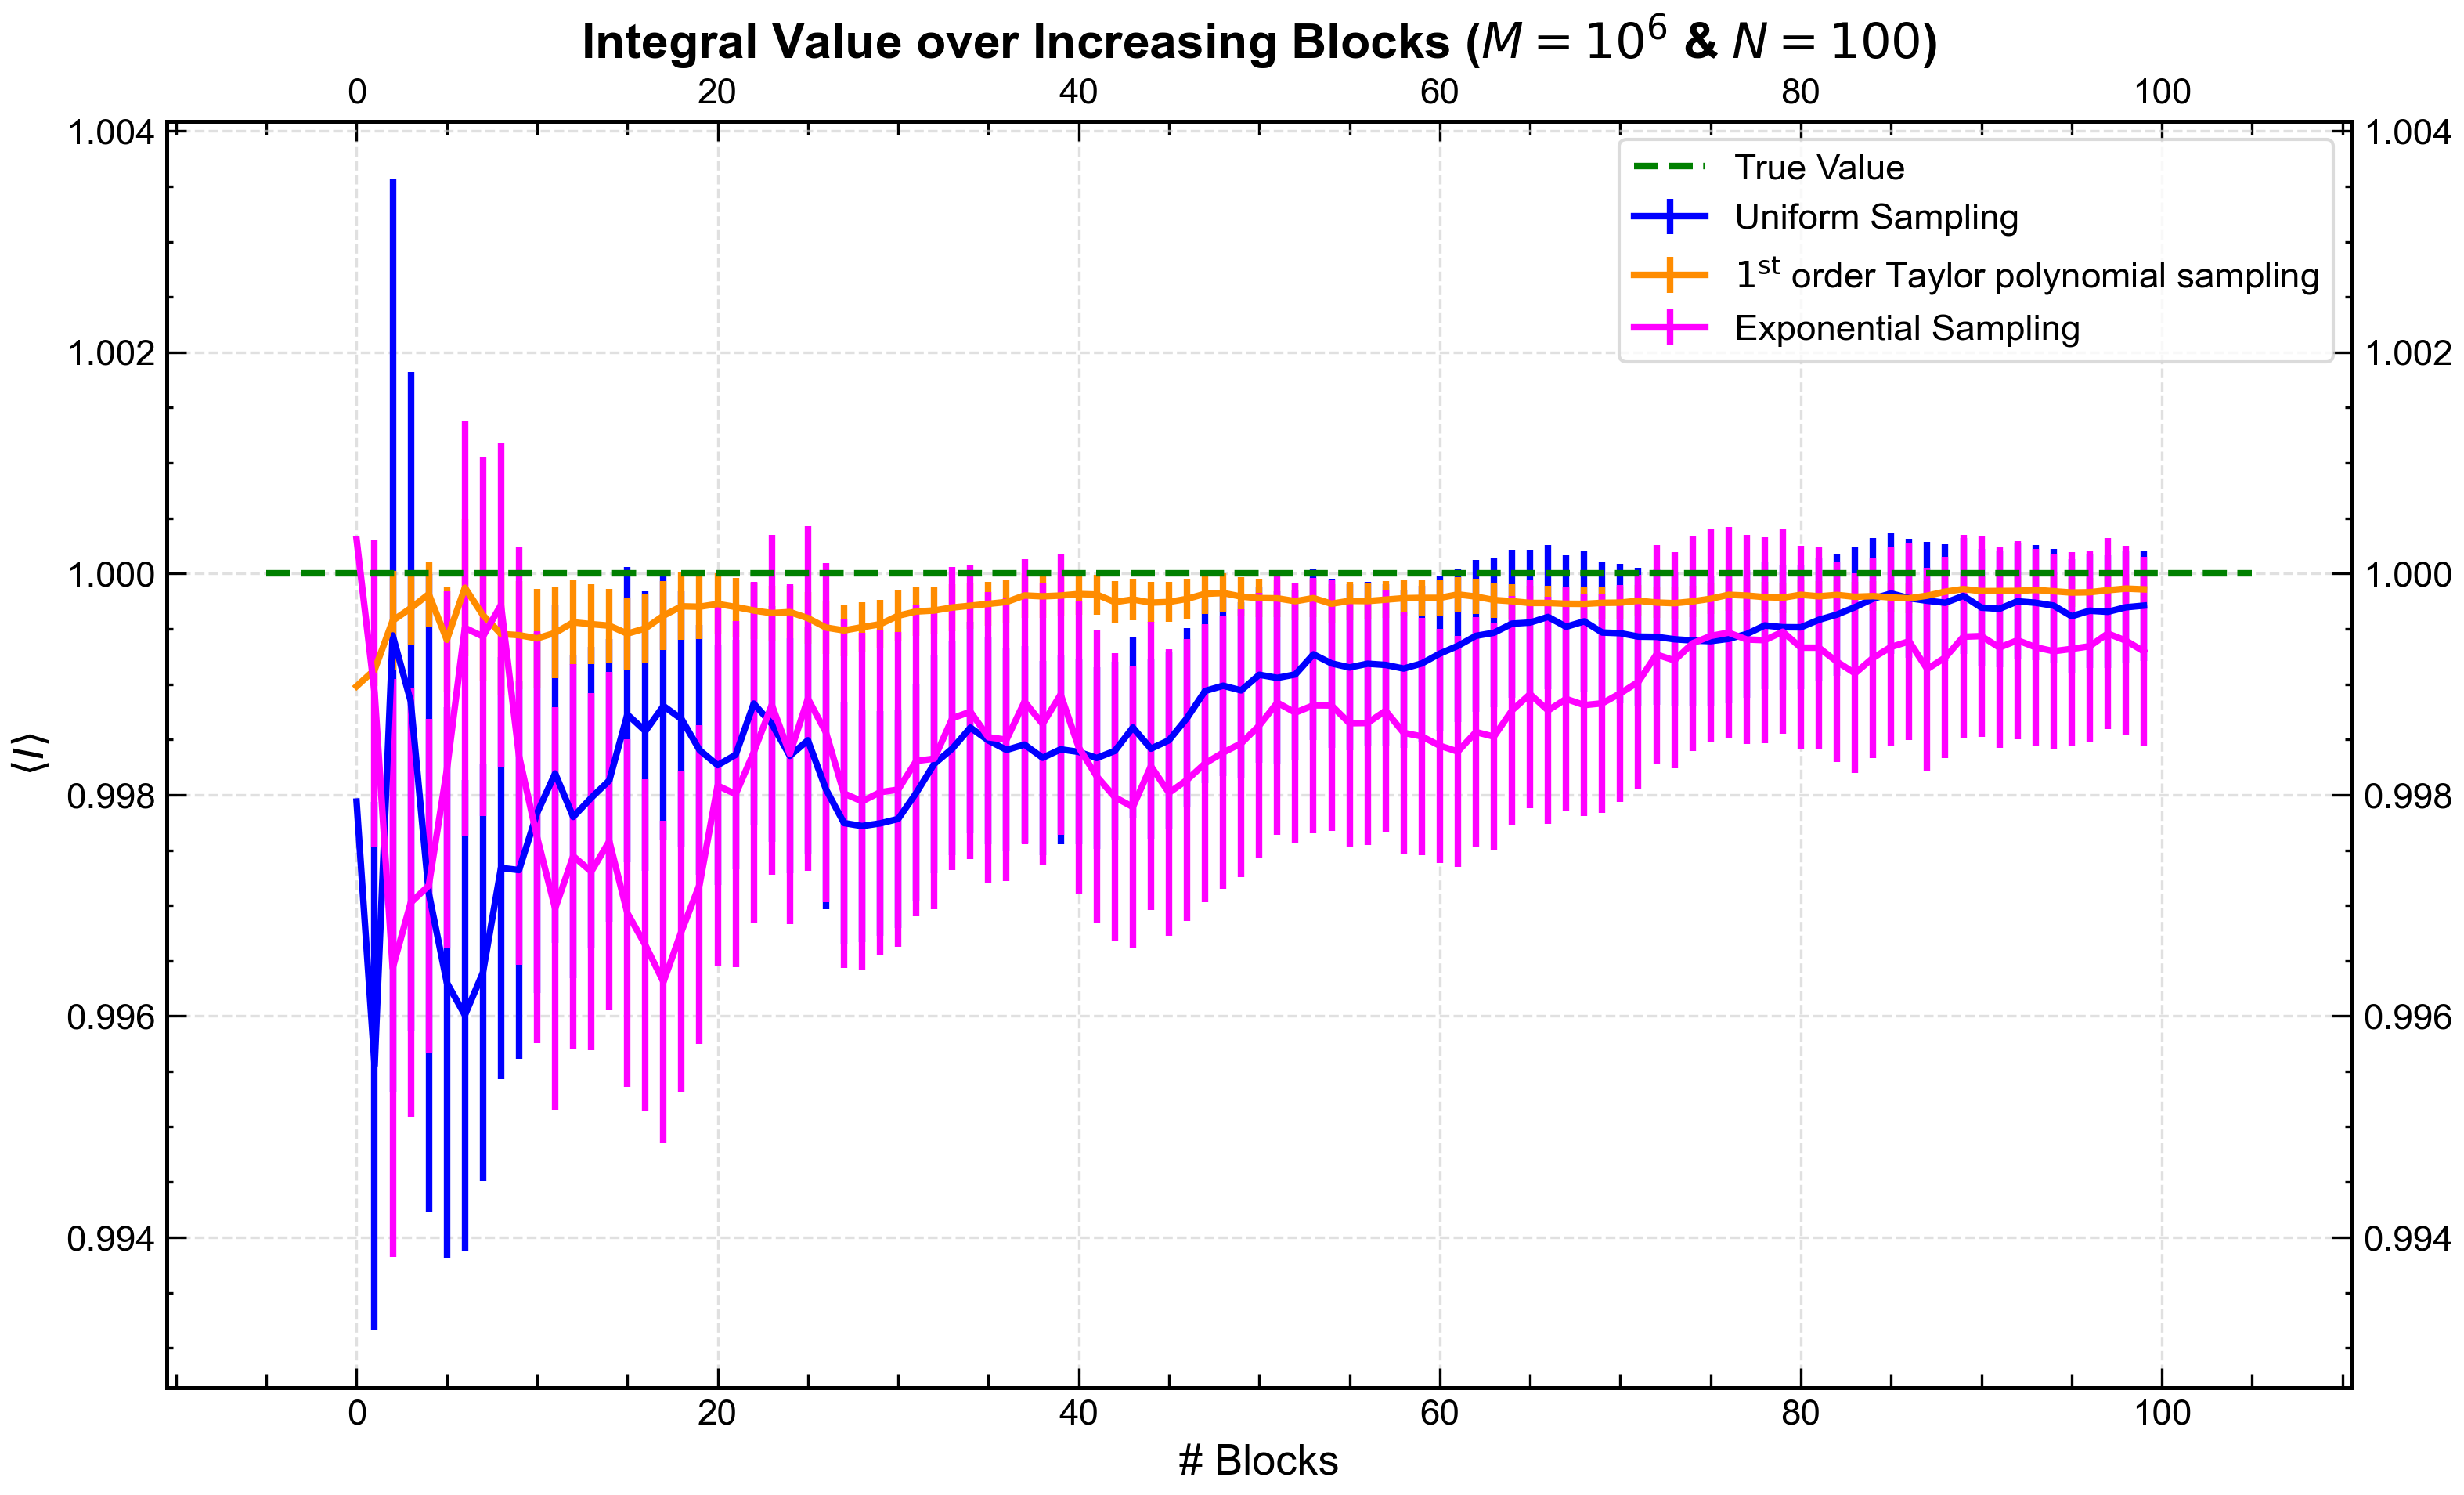

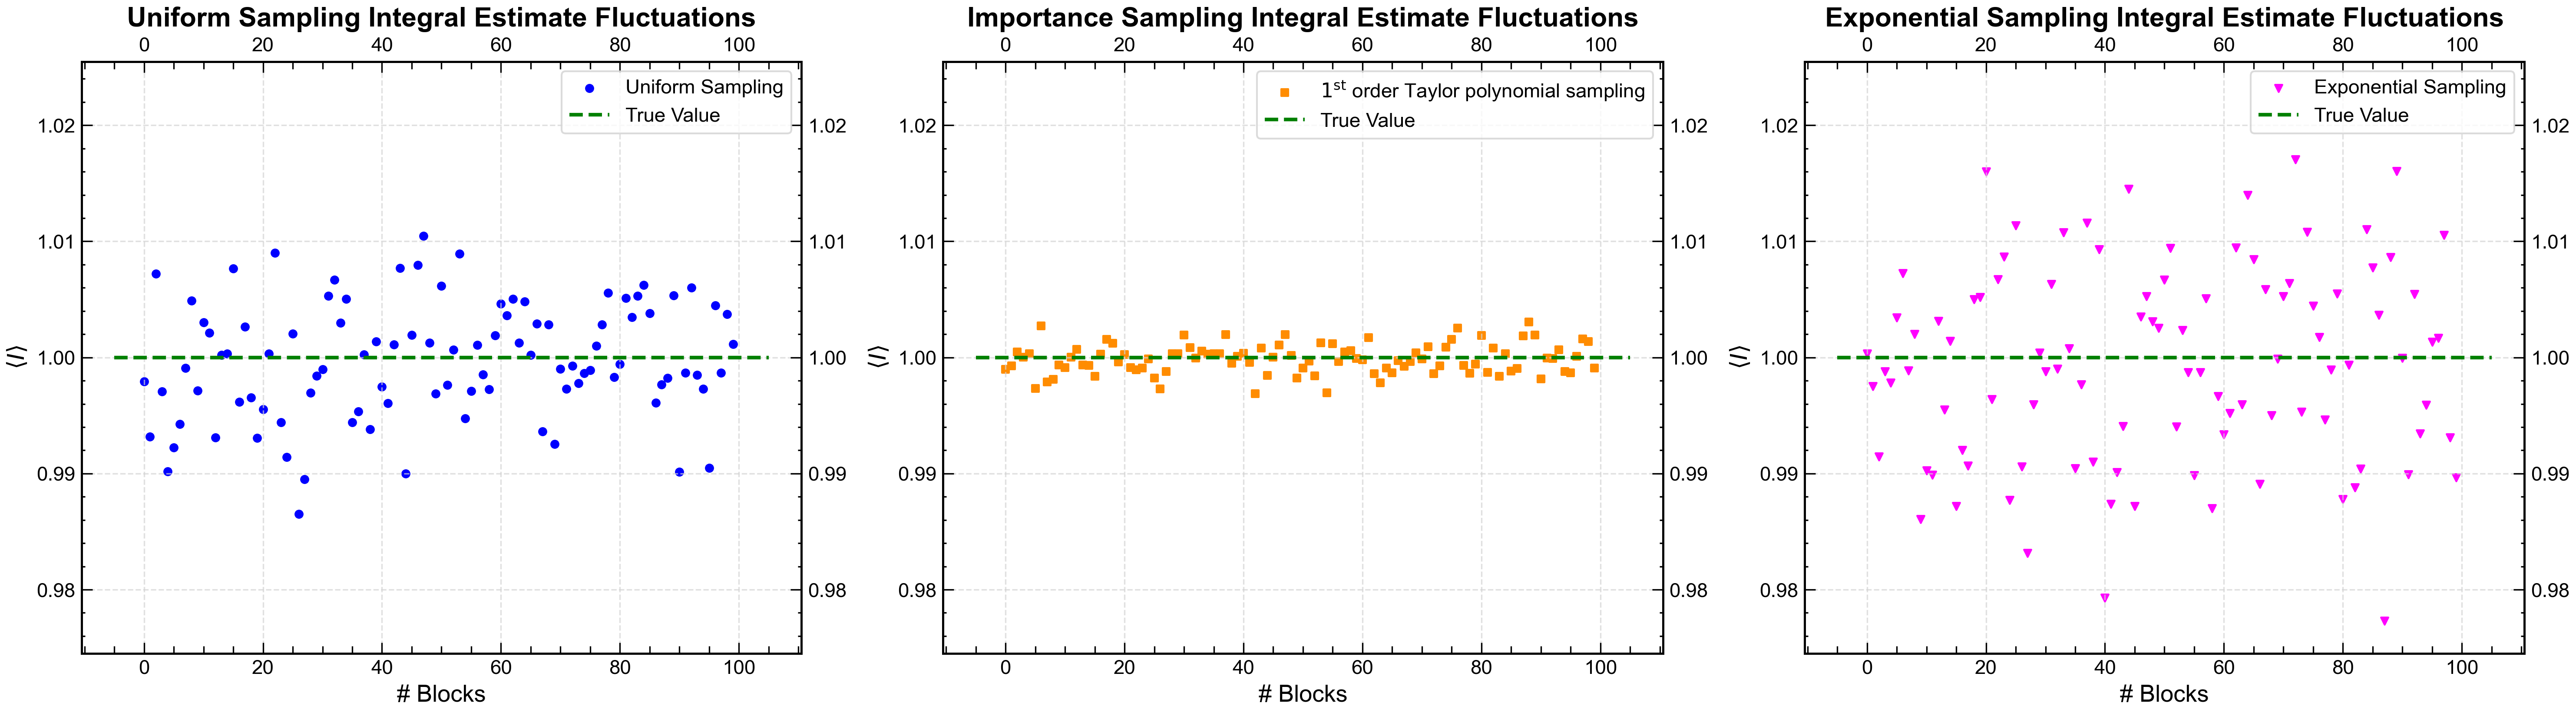

In [2]:
# =========================================================
# CONFIGURATION AND DATA LOADING
# =========================================================

# Number of blocks used in the Monte Carlo simulation (N=100)
N = 100
# The known analytical solution for the integral I
true_value = 1.0 

# Load cumulative data for Uniform Sampling
# usecols=(0, 2, 3) loads: Block Index (x), Cumulative Mean (val), and Cumulative Error (error)
x, val, error = np.loadtxt("es_2.1/OUTPUT/mean_error_uniform_sampling.data", usecols = (0,2,3), unpack = True)
# Load cumulative data for Importance Sampling
# usecols=(2, 3) loads: Cumulative Mean (val2) and Cumulative Error (error2)
val2, error2 = np.loadtxt("es_2.1/OUTPUT/mean_error_importance_sampling.data", usecols = (2,3), unpack = True)
val3, error3 = np.loadtxt("es_2.1/OUTPUT/mean_error_exponential_sampling.data", usecols = (2,3), unpack = True)


# =========================================================
# PLOT 1: CUMULATIVE MEAN CONVERGENCE
# =========================================================

fig = plt.figure(figsize = (12,7) )
# Set the title for the cumulative convergence plot
plt.title("Integral Value over Increasing Blocks ($M = 10^6$ & $N = 100$)")

# Plot 1a: Uniform Sampling convergence (with error bars)
plt.errorbar(x, val, color = "blue" , yerr = error, label = "Uniform Sampling")
# Plot 1b: Importance Sampling convergence (with error bars)
plt.errorbar(x, val2, color = "darkorange" , yerr = error2, label = r"$1^{\text{st}}$ order Taylor polynomial sampling")
# Plot 1c: Exponential Sampling convergence (with error bars)
plt.errorbar(x, val3, color = "fuchsia" , yerr = error3, label = "Exponential Sampling")

# Horizontal line indicating the true analytical value
plt.hlines(true_value, -5, N + 5, linestyle = "--", color = "green", label = "True Value")
plt.legend()
plt.xlabel('# Blocks')
# Set the LaTeX expression for the Y-axis label (Expected Value of I)
plt.ylabel(r"$\langle I \rangle$")
# plt.grid(True) # Grid is typically managed by the global rcParams

plt.savefig("es_2.1/plot/mean_value_over_blocks.png")


# =========================================================
# RESULTS SUMMARY (Console Output)
# =========================================================

print("UNIFORM SAMPLING :\nBest integral value : ", round(val[-1], 4), "±", round(error[-1], 4))
print("distance from true value in sigma units : ", round(abs(val[-1] - true_value)/error[-1], 2), "sigma")

print("IMPORTANCE SAMPLING :\nBest integral value : ", round(val2[-1], 5), "±", round(error2[-1], 5))
print("distance from true value in sigma units : ", round(abs(val2[-1] - true_value)/error2[-1], 2), "sigma")

print("EXPONENTIAL SAMPLING :\nBest integral value : ", round(val3[-1], 5), "±", round(error3[-1], 5))
print("distance from true value in sigma units : ", round(abs(val3[-1] - true_value)/error3[-1], 2), "sigma")


# =========================================================
# PLOT 2: BLOCK ESTIMATE FLUCTUATIONS (SCATTER PLOTS)
# =========================================================

# Load the mean value *of each block* (Column 1)
val = np.loadtxt("es_2.1/OUTPUT/mean_error_uniform_sampling.data", usecols = (1))
val2 = np.loadtxt("es_2.1/OUTPUT/mean_error_importance_sampling.data", usecols = (1))
val3 = np.loadtxt("es_2.1/OUTPUT/mean_error_exponential_sampling.data", usecols = (1))

# Create a figure with two subplots side-by-side (sharing the X-axis)
fig, (ax1, ax2, ax3) = plt.subplots(1, 3, figsize=(20, 6), sharex=True)

# Calculate standard deviation to be used to set both y-axis 
y_axis_width_par = np.std(val3) 

# --- Subplot 1: Uniform Sampling Block Fluctuations ---
ax1.scatter(x, val, color = "blue", marker = "o", label = "Uniform Sampling")
ax1.hlines(true_value, -5, N + 5, linestyle = "--", color = "green", label = "True Value")

ax1.set_title("Uniform Sampling Integral Estimate Fluctuations")
ax1.set_xlabel("# Blocks")
ax1.set_ylabel(r"$\langle I \rangle$")

# --- Subplot 2: Importance Sampling Block Fluctuations ---
ax2.scatter(x, val2, color = "darkorange", marker = "s", label = r"$1^{\text{st}}$ order Taylor polynomial sampling") # Marker changed to 's' for better visibility
ax2.hlines(true_value, -5, N + 5, linestyle = "--", color = "green", label = "True Value")

ax2.set_title("Importance Sampling Integral Estimate Fluctuations")
ax2.set_xlabel("# Blocks")
ax2.set_ylabel(r"$\langle I \rangle$")

# --- Subplot 3: Exponential Sampling Block Fluctuations ---
ax3.scatter(x, val3, color = "fuchsia", marker = "v", label = "Exponential Sampling") # Marker changed to 's' for better visibility
ax3.hlines(true_value, -5, N + 5, linestyle = "--", color = "green", label = "True Value")

ax3.set_title("Exponential Sampling Integral Estimate Fluctuations")
ax3.set_xlabel("# Blocks")
ax3.set_ylabel(r"$\langle I \rangle$")

# --- Y-Axis Range Setting ---
# Set Y-limits to ± 3 standard deviations around the true value for both method to show with same y-axis width fluctuations differences 
ax1.set_ylim(true_value - 3 * y_axis_width_par, true_value + 3 * y_axis_width_par)
ax1.legend()
ax2.set_ylim(true_value - 3 * y_axis_width_par, true_value + 3 * y_axis_width_par) 
ax2.legend()
ax3.set_ylim(true_value - 3 * y_axis_width_par, true_value + 3 * y_axis_width_par) 
ax3.legend()


# Final layout adjustment and saving
plt.tight_layout(rect=[0, 0.03, 1, 0.98])
plt.savefig("es_2.1/plot/mean_block_scatter_comparison.png")

plt.show()

<h4>Conclusion</h4>

Monte Carlo **Uniform Sampling (US)** over $10^6$ total throws returns an estimate for the integral equal to:
$$\langle I \rangle_{\text{US}} = 0.9997 \pm 0.0005$$
Its distance from the **true value** is $0.58\sigma$.

Monte Carlo **Importance Sampling (IS)** using $1^{\text{st}}$ order Taylor polynomial expansion over $10^6$ total throws returns an estimate for the integral equal to:
$$\langle I \rangle_{\text{IS}} = 0.99986 \pm 0.00013$$
Its distance from the true value is $1.12\sigma$.

Monte Carlo **Importance Sampling (IS)** using an exponential PDF over $10^6$ total throws returns an estimate for the integral equal to:
$$\langle I \rangle_{\text{IS}} = 0.9993 \pm 0.00085$$
Its distance from the true value is $0.82\sigma$.

All results are **statistically consistent** as their deviations from the true value are well within the typical confidence interval (e.g., $3\sigma$). The plots clearly demonstrate the effectiveness of the Importance Sampling method:

- The **first plot** shows the convergence of the **cumulative mean** value towards the true value. The IS simulation starts closer to the true value and its progressive uncertainty is significantly smaller than the uniform one. This is quantified by the fact that the ratio of the final standard deviations is $\sigma_{\text{IS}}/\sigma_{\text{US}} \approx 0.26$, confirming the **variance reduction**.

- The **second plot** illustrates the integral value fluctuations across the $N=100$ individual blocks. The **Uniform Sampling** estimates show substantially larger block-to-block fluctuations than the **Importance Sampling** estimates. This low fluctuation rate explains why the IS simulation produced a smaller final uncertainty, validating the theoretical goal of Importance Sampling.

- The **supplementary integral estimation** using the exponential PDF provides **further evidence** that the estimator's **variance depends on the fidelity of the approximation** provided by the sampling PDF relative to the integrand.

<a id="stochastic-processes"></a>
## <span style="color:darkviolet">Stochastic Processes</span>

A **stochastic process** is defined as a family $(X_{t})_{t \in \mathbb{A}}$ of **random variables** with a *time index*. The index set $\mathbb{A}$ can be discrete or continuous, which leads to two different types of stochastic processes:

- **Discrete-time** stochastic process $(X_n)_{n \in \mathbb{N}}$, where $n \in \mathbb{N}$.
- **Continuous-time** stochastic process $(X_t)_{t \in \mathbb{T}}$, where $\mathbb{T} \subseteq \mathbb{R}$ is typically an interval.

It is important to note that, for a **fixed** time index $t$, the random variable $X_t$ describing the state of the stochastic process at that instant is treated as a standard, time-**independent** random variable. Therefore, we can utilize all the criteria and theorems of probability and statistics.

The most important quantity describing a stochastic process is the $\mathbf{n}$-event **joint probability density function (PDF)**:

$$p_n(x_1, t_1; \dots ; x_n, t_n)$$

which describes the probability density that the process is in state $x_1$ at time $t_1$, ..., and in state $x_n$ at time $t_n$. It is important to know that for most stochastic processes, determining its analytical form is very difficult.

The joint PDF fulfills the following properties:

- **Positivity**: $p_n(x_1, t_1; \dots ; x_n, t_n) \ge 0$.

- **Normalization/Consistency (Marginalization)**:
$$\int dx_n~p_n(x_1, t_1; \dots ; x_n, t_n) = p_{n-1}(x_1, t_1; \dots ; x_{n-1}, t_{n-1})$$

- The **one-event marginal PDF** is a properly normalized probability density function (i.e., $\int dx p_1(x;t) = 1$).


Once the $n$-event joint probability density function is known, we can compute the **time-dependent mean value**, and the **time-dependent covariance matrix** (whose diagonal elements define the **autocorrelation function** in the case of a scalar process, or a related function for the matrix elements).

It is also possible to define the **conditional probability density function** of a stochastic process to gain information about its sub-ensembles. The $(k+l)$-event joint PDF is given by the product of the conditional probability density function for the $l$ events (given that the $k$ events have occurred) and the $k$-event joint PDF:

$$p_{k+l}(x_1, t_1; \dots ; x_{k+l}, t_{k+l}) = p_{l \mid k}(x_{k+1}, t_{k+1}; \dots ; x_{k+l}, t_{k+l} \mid x_1, t_1; \dots ; x_{k}, t_{k}) \cdot p_{k}(x_1, t_1; \dots ; x_{k}, t_{k}).$$

A stochastic process is defined **stationary** if and only if its $n$-event joint probability density function is invariant under a shift in time $\Delta t$ for all $n$:

$$p_n(x_1, t_1 + \Delta t; \dots ; x_n, t_n+ \Delta t) = p_n(x_1, t_1; \dots ; x_n, t_n) \quad \forall n, \Delta t.$$

<a id="markov-processes-and-random-walks"></a>
<h3><span style="color:darkviolet">Markov processes and Random Walks</span></h3>

**Random Walks** are a mathematical formalization of a trajectory that consists of taking successive random steps. They are an example of **Markov Chains** (when the state space is discrete) or **Markov Processes** (in general). These processes are often considered the "ideal gas" of stochastic processes due to their simplicity.

These types of processes are characterized by being **memoryless** (or possessing the **Markov Property**). This means that the conditional probability of the next state $X_{t_n}$, given all preceding states $(X_{t_1}, \dots, X_{t_{n-1}})$, depends only on the immediately preceding state $X_{t_{n-1}}$:

$$p_{1 \mid n-1}(x_n, t_n \mid x_1, t_1; \dots ; x_{n-1}, t_{n-1}) = p_{1 \mid 1}(x_n, t_n \mid x_{n-1}, t_{n-1}).$$

In this case, the $n$-event joint probability density function can be expressed as a chain of products:

$$p_n(x_1, t_1; ... ; x_n, t_n) = \prod_{l = 2}^{n}p_{1 \mid 1}(x_l, t_l \mid x_{l-1}, t_{l-1})p_1(x_1, t_1).$$

It can be shown that two positive and normalized functions, the initial probability $p_1(x_1, t_1)$ and the two-time transition probability $p_{1 \mid 1}$, which fulfill:

- The **Chapman–Kolmogorov equation**:
$$p_{1 \mid 1}(x_n, t_n \mid x_1, t_1) = \int dx_2 \cdot \dots \cdot \int dx_{n-1} \left[ \prod_{j = 2}^{n}p_{1 \mid 1}(x_j, t_j \mid x_{j-1}, t_{j-1}) \right] \quad \text{for} \quad t_n \ge \dots \ge t_1;$$

- The **normalization/consistency condition** for the probability density function,

**completely and uniquely define** a Markov process.

We can treat a **Random Walk** as a discrete-time, discrete-space Markov process. If we consider a **1D Symmetric Random Walk**, the probability to find the system at position $x = na$ (where $a$ is the lattice spacing) after $s+1$ time steps is given by the total probability theorem applied to the one-step transition:

$$p_1(na, (s+1)\tau) = \sum_{m = - \infty}^{+ \infty}p_{1 \mid 1}(na, (s+1) \tau \mid ma, s \tau)p_1(ma, s \tau),$$

where $p_{1 \mid 1}(na, (s+1) \tau \mid ma, s \tau)$ describes the **transition probability** to move from *any* possible lattice position $x = ma$ at time $t = s \tau$ to position $x = na$ in one step.

Since, in a symmetric nearest-neighbor Random Walk, a step can occur only between adjacent sites, the transition probability becomes:

$$p_{1 \mid 1}(na, (s+1) \tau \mid ma, s \tau) = \frac{1}{2}\left(\delta_{n+1, m} + \delta_{n-1, m}\right),$$

and substituting this into the master equation, the probability distribution evolves according to:

$$p_1(na, (s+1)\tau) = \frac{p_1((n-1)a, s \tau) + p_1((n+1)a, s \tau)}{2}.$$

By taking the continuous limit ($a \to 0$ and $\tau \to 0$ while keeping $D = \frac{a^2}{2\tau}$ constant), we can obtain a **Partial Differential Equation (PDE)** for the probability density $p_1(x,t)$, which describes the **diffusion process**:

$$ \frac{\partial p_1(x,t)}{\partial t} = D\frac{\partial^{2}p_1(x,t)}{\partial x^2},$$

where $D = \frac{a^2}{2\tau}$ is called the **diffusivity** or **diffusion coefficient**.

This PDE, with the initial condition $p_1(x, 0) = \delta (x)$ (which means the system is certainly at position $x=0$ at time $t=0$), can be solved using the Fourier Transform method. The final solution is given by the inverse Fourier transform:

$$p_1(x, t) = \mathcal{F}^{-1}\{\hat{p}_1(k, t)\} = \frac{1}{2 \pi}\int_{- \infty}^{+ \infty}dk e^{ikx}\hat{p}_1(k, t) = \frac{1}{2 \pi}\int_{- \infty}^{+ \infty}dk e^{ikx} e^{-Dtk^2} = \frac{1}{\sqrt{4 \pi D t}} e^{- \frac{x^2}{4Dt}}$$

which is a **Gaussian distribution** with mean value $\langle x(t) \rangle = 0$ and variance $\langle x^2(t) \rangle = 2Dt$. Since the time $t$ is linked to the total number of steps in the Random Walk, we can conclude that, starting from a localized state (Dirac delta), the system evolves over time by **spreading its probability width** (diffusing).

<a id="clt-and-random-walks"></a>
<h3><span style="color:darkviolet">CLT and Random Walks</span></h3>

We can also represent the **Random Walk** as a case study for the **Central Limit Theorem (CLT)**. In this context, the random variable "$S_N$", defined by the CLT as the sum of $N$ independent random variables, $S_N = \sum_{i = 1}^{N}X_i$, can be seen as the system's position after $N$ steps.

In the case of a 1D symmetric Random Walk with step size $a$, the component random variables $X_i$ are **independent and identically distributed (i.i.d.)** with the following probability distribution (or probability mass function, since it's discrete):

$$P(X_i = x) = 0.5 \left[ \delta(x-a) + \delta(x+a) \right]$$

These variables have:
1.  **Mean Value**: $\langle X_i \rangle = \int_{-\infty}^{+\infty} dx\, x P(X_i=x) = (a) \cdot 0.5 + (-a) \cdot 0.5 = 0$.
2.  **Variance**: $\sigma_{i}^{2} = \int_{-\infty}^{+\infty} dx\, x^{2} P(X_i=x) = (a^2) \cdot 0.5 + (-a)^2 \cdot 0.5 = a^2 < \infty$.

The Central Limit Theorem (CLT) states that, as the number of steps $N \to \infty$:

1.  **Expected Position (Mean)**:
    $$\langle S_N \rangle \to N \langle X \rangle = 0$$
2.  **Variance of Position**:
    $$\sigma^{2}_{S_N} \to N \sigma^2 = N a^2$$
3.  **Distribution Convergence (The PDF of $S_N$)**:
    The probability distribution function $P_N(S_N)$ converges to a **Normal (Gaussian) distribution**:
    $$P_N(S_N) \to \frac{1}{\sqrt{2 \pi N a^2}} e^{- \frac{S_{N}^{2}}{2 N a^2}} \quad \text{as } N \to \infty$$

Point 3 is entirely consistent with the result obtained from solving the diffusion equation in the continuous limit. To match the previous result where time $t$ was involved, we note that $t = N \tau$, $D = a^2 / (2\tau)$, and thus the variance $\sigma_{S_N}^2 = N a^2$ corresponds exactly to $2Dt$ when $\tau$ is the time step duration:
$$\sigma_{S_N}^2 = N a^2 = \left(\frac{t}{\tau}\right) a^2 = t \left(\frac{a^2}{\tau}\right) = 2D t.$$

<a id="bernoulli-processes-and-random-walks"></a>
<h4><span style="color:darkviolet">Bernoulli processes and Random Walks</span></h4>

A **Random Walk (RW)** can also be modeled using a **Bernoulli process**. A Bernoulli process consists of a sequence of **independent and identically distributed (i.i.d.)** random variables that describe the occurrence or non-occurrence of an event.

Specifically, a Bernoulli trial (or step) is characterized by:

-   Each event is described by a random variable $X_i \in \{0, 1\}$, where $1$ denotes "success" and $0$ denotes "failure."
-   The probability associated with a success is constant (time-independent) for every trial: $P(X_i = 1) = p$ and $P(X_i = 0) = 1-p$.

It is possible to define a **Bernoulli Sum variable** $B_n$ as the total number of successes after $n$ trials:

$$B_n = \sum_{i=1}^{n} X_i = B_{n-1} + X_n,$$

where $B_{n-1}$ is the total number of successes up to step $n-1$, and the random variable $X_n$ is defined by:

$$ X_n = 
\begin{cases}
1   & \text{with probability } p \\ 
0   & \text{with probability } 1-p \\ 
\end{cases}$$

The variable $B_n$ counts the total number of successes (ones), but does not directly represent the position in a standard 1D Random Walk.
To represent the walker's position, we need a transformation from the Bernoulli variable $X_n$ (which gives 0 or 1) to a step variable $S_n$ (which gives $-1$ or $+1$, setting the step size $a=1$ for simplicity):

$$\text{Step } S_n = 2X_n - 1$$

If $X_n=1$ (success, probability $p$), then $S_n = 2(1) - 1 = +1$ (move right).
If $X_n=0$ (failure, probability $1-p$), then $S_n = 2(0) - 1 = -1$ (move left).

The walker's position $R_n$ at step $n$ is the cumulative sum of these steps:

$$R_n = \sum_{i=1}^{n} S_i = \sum_{i=1}^{n} (2X_i - 1)$$

This can be related back to the Bernoulli Sum $B_n$:

$$R_n = 2 \left( \sum_{i=1}^{n} X_i \right) - \sum_{i=1}^{n} 1 = 2B_n - n$$

The equation describing the position of the 1D Random Walk is then given by the recursive relation:

$$R_n = R_{n-1} + S_n = R_{n-1} + (2X_n - 1)$$

Choosing the step probability $p = 0.5$ results in the **symmetric 1D Random Walk**, where the walker has an equal probability of moving left $(-1)$ or right $(+1)$ at each step.

<a id="random-walk-simulation"></a>
<h2><span style="color:darkviolet">Random Walk Simulation</span></h2>

In this section we want to perform $10^4$ 3D Random Walk always starting at the origin :
- on a *cubic lattice* with lattice constant $a = 1$ in which at each discrete time step ($\tau = 1$) the walker makes a forward or backward step of length equal to $a$ in one of the 3 principal direction of the lattice ($x$, $y$ or $z$)

- *in the continuum* in which at each discrete time step ($\tau = 1$) the walker makes a step of length equal to $a = 1$ along a random direction obtain by sampling uniformly the solid angle $\theta \in [0,\pi]$ and $\phi \in [0,2\pi]$.

We want to show a picture of $\sqrt{ \langle |\vec{r}_N|^2 \rangle_{RW}}$ for both RWs, with their statistical uncertainties, as function of the step $i\in [0,10^2]$ and see if the RWs simulated indicate a diffusive behavior.

<h4>Implementation</h4>

The simulation is built upon a modular C++ structure: 
- the `Random` class class provides the pseudo-random number generation (using the LCG algorithm);
- the `Randomwalk` class  handles the stochastic process, measurement, and statistical analysis;
- `main.cpp` manages the overall execution flow, which strictly follows the *Blocking Averaging Method*.

<h4><span style="color:darkviolet">Random Walk class</span></h4>

The class models the walker's movement and manages statistical data accumulation. All statistical accumulators are Armadillo vectors (`arma::vec`) sized to `_nstep` ($100$), where each component tracks data corresponding to a specific time step *k*.

<h5><span style="color:darkviolet">Initialization and Configuration Methods</span></h5>

- *initialize()*: Reads core simulation parameters (`_nwalks`, `_nblocks`, `_nstep`, `_step`, `_RWtype`) from `input.dat`.
- *initialize_properties()*: Reads boolean flags from `properties.dat` to estabilish whose optional measures will be executed and sets output files format.
- *reset_position()*: Resets the walker's current position vector (`_x`) to the starting position (`_xstart`).



<h5><span style="color:darkviolet">Movement Sampling Method</span></h5>

The *step()* method is the core of the simulation, responsible for advancing the walker by a fixed distance `_step` at each time unit. Its implementation is conditional on the selected Random Walk type (`_RWtype`).

1. **Discrete Random Walk**
    - Axis Selection (Direction): The axis of movement (index $d \in \{0, 1, 2, \dots, \text{_ndim}-1$) is selected uniformly among the available dimensions.
    ````cpp
            int direction = int(_ndim * _rnd.Rannyu());
    ````
    - Sign Selection: The step direction, ±1, is chosen with equal probability ($0.5$).
    ````cpp
            int sign{(_rnd.Rannyu() < 0.5 ? -1 : 1)};
    ````
    The current position `_x` is then updated by:
    ````cpp
            _x.at(direction) += sign * _step;
    ````

2. **Continuous Random Walk**
    - Azimuthal Angle ($\phi$) Sampling: Sampled uniformly in the interval $[0,2 \pi]$.
    ````cpp
            double phi{_rnd.Rannyu(0.0, 2.0*M_PI)};
    ````
    - Polar Angle ($\theta$) Sampling: To achieve a uniform distribution over the sphere's surface, $\mathrm{cos}(\theta)$ must be sampled uniformly in $[−1,1]$. This is implemented via the inverse transform method:
    ````cpp
            double theta{acos(1 - 2.0*_rnd.Rannyu())};
    ````
    The current position `_x` is then updated by:
    ````cpp
            _x.at(0) += _step * sin(theta) * cos(phi);
            _x.at(1) += _step * sin(theta) * sin(phi);
            _x.at(2) += _step * cos(theta);
    ````

<h5><span style="color:darkviolet">Block Averaging Method</span></h5>

The Block Averaging Method is implemented to estimate the root-mean-square displacement,  $\sqrt{\langle r^2 \rangle}$, and its statistical uncertainty over time steps.

**Data Accumulation**
- *get_distance2()*: Computes the squared displacement $r^2(k)$ at any given step *k*.

- *measure(int step)*: Accumulates the value $r^2(k)$ into the k-th component of the `_dist2acc` vector (`_dist2acc.at(k)`), which serves as the block accumulator for $\langle r^2 \rangle$.

- *reset_block(int blk)*: Zeros the components of the `_dist2acc` vector after a block is completed.

**Statistical Analysis**
- *averages(int blk)*: Performs the statistical analysis at the end of block i:
    1. Calculates the block mean $\langle r^2 \rangle _{block,k}$ for all steps *k*.
    2. Updates the progressive accumulators: 
        - `_meanacc`: sum of the $\sqrt{\langle r^2 \rangle _{block}}$;
        - `_mean2acc`: sum of the squared estimates $\langle r^2 \rangle _{block}$.
    3. Calculates the progressive mean ($\sqrt{\langle r^2 \rangle}$) and the statistical uncertainty for each step, and writes the results to output files.

- *error(double mean, double mean2, int blk)*: Computes the progressive statistical error using the standard deviation of the block means.

<h4><span style="color:darkviolet">Main.cpp structure</span></h4>

The `main.cpp` file initializes the simulation parameters and orchestrates the entire process, strictly adhering to the *Block Averaging Method* through a **three-nested loop structure**:
- **Inner Loop** (over `_nstep`): Simulates the time evolution of a single trajectory and collects the raw data for that specific RW.
- **Middle Loop** (over `_nwalksperblock`): Aggregates the simulation results over all `_nwalksperblock` independent trajectories.
- **Outer Loop** (over `_nblocks`): computes the block average and its contribution to the final progressive mean and error estimate.



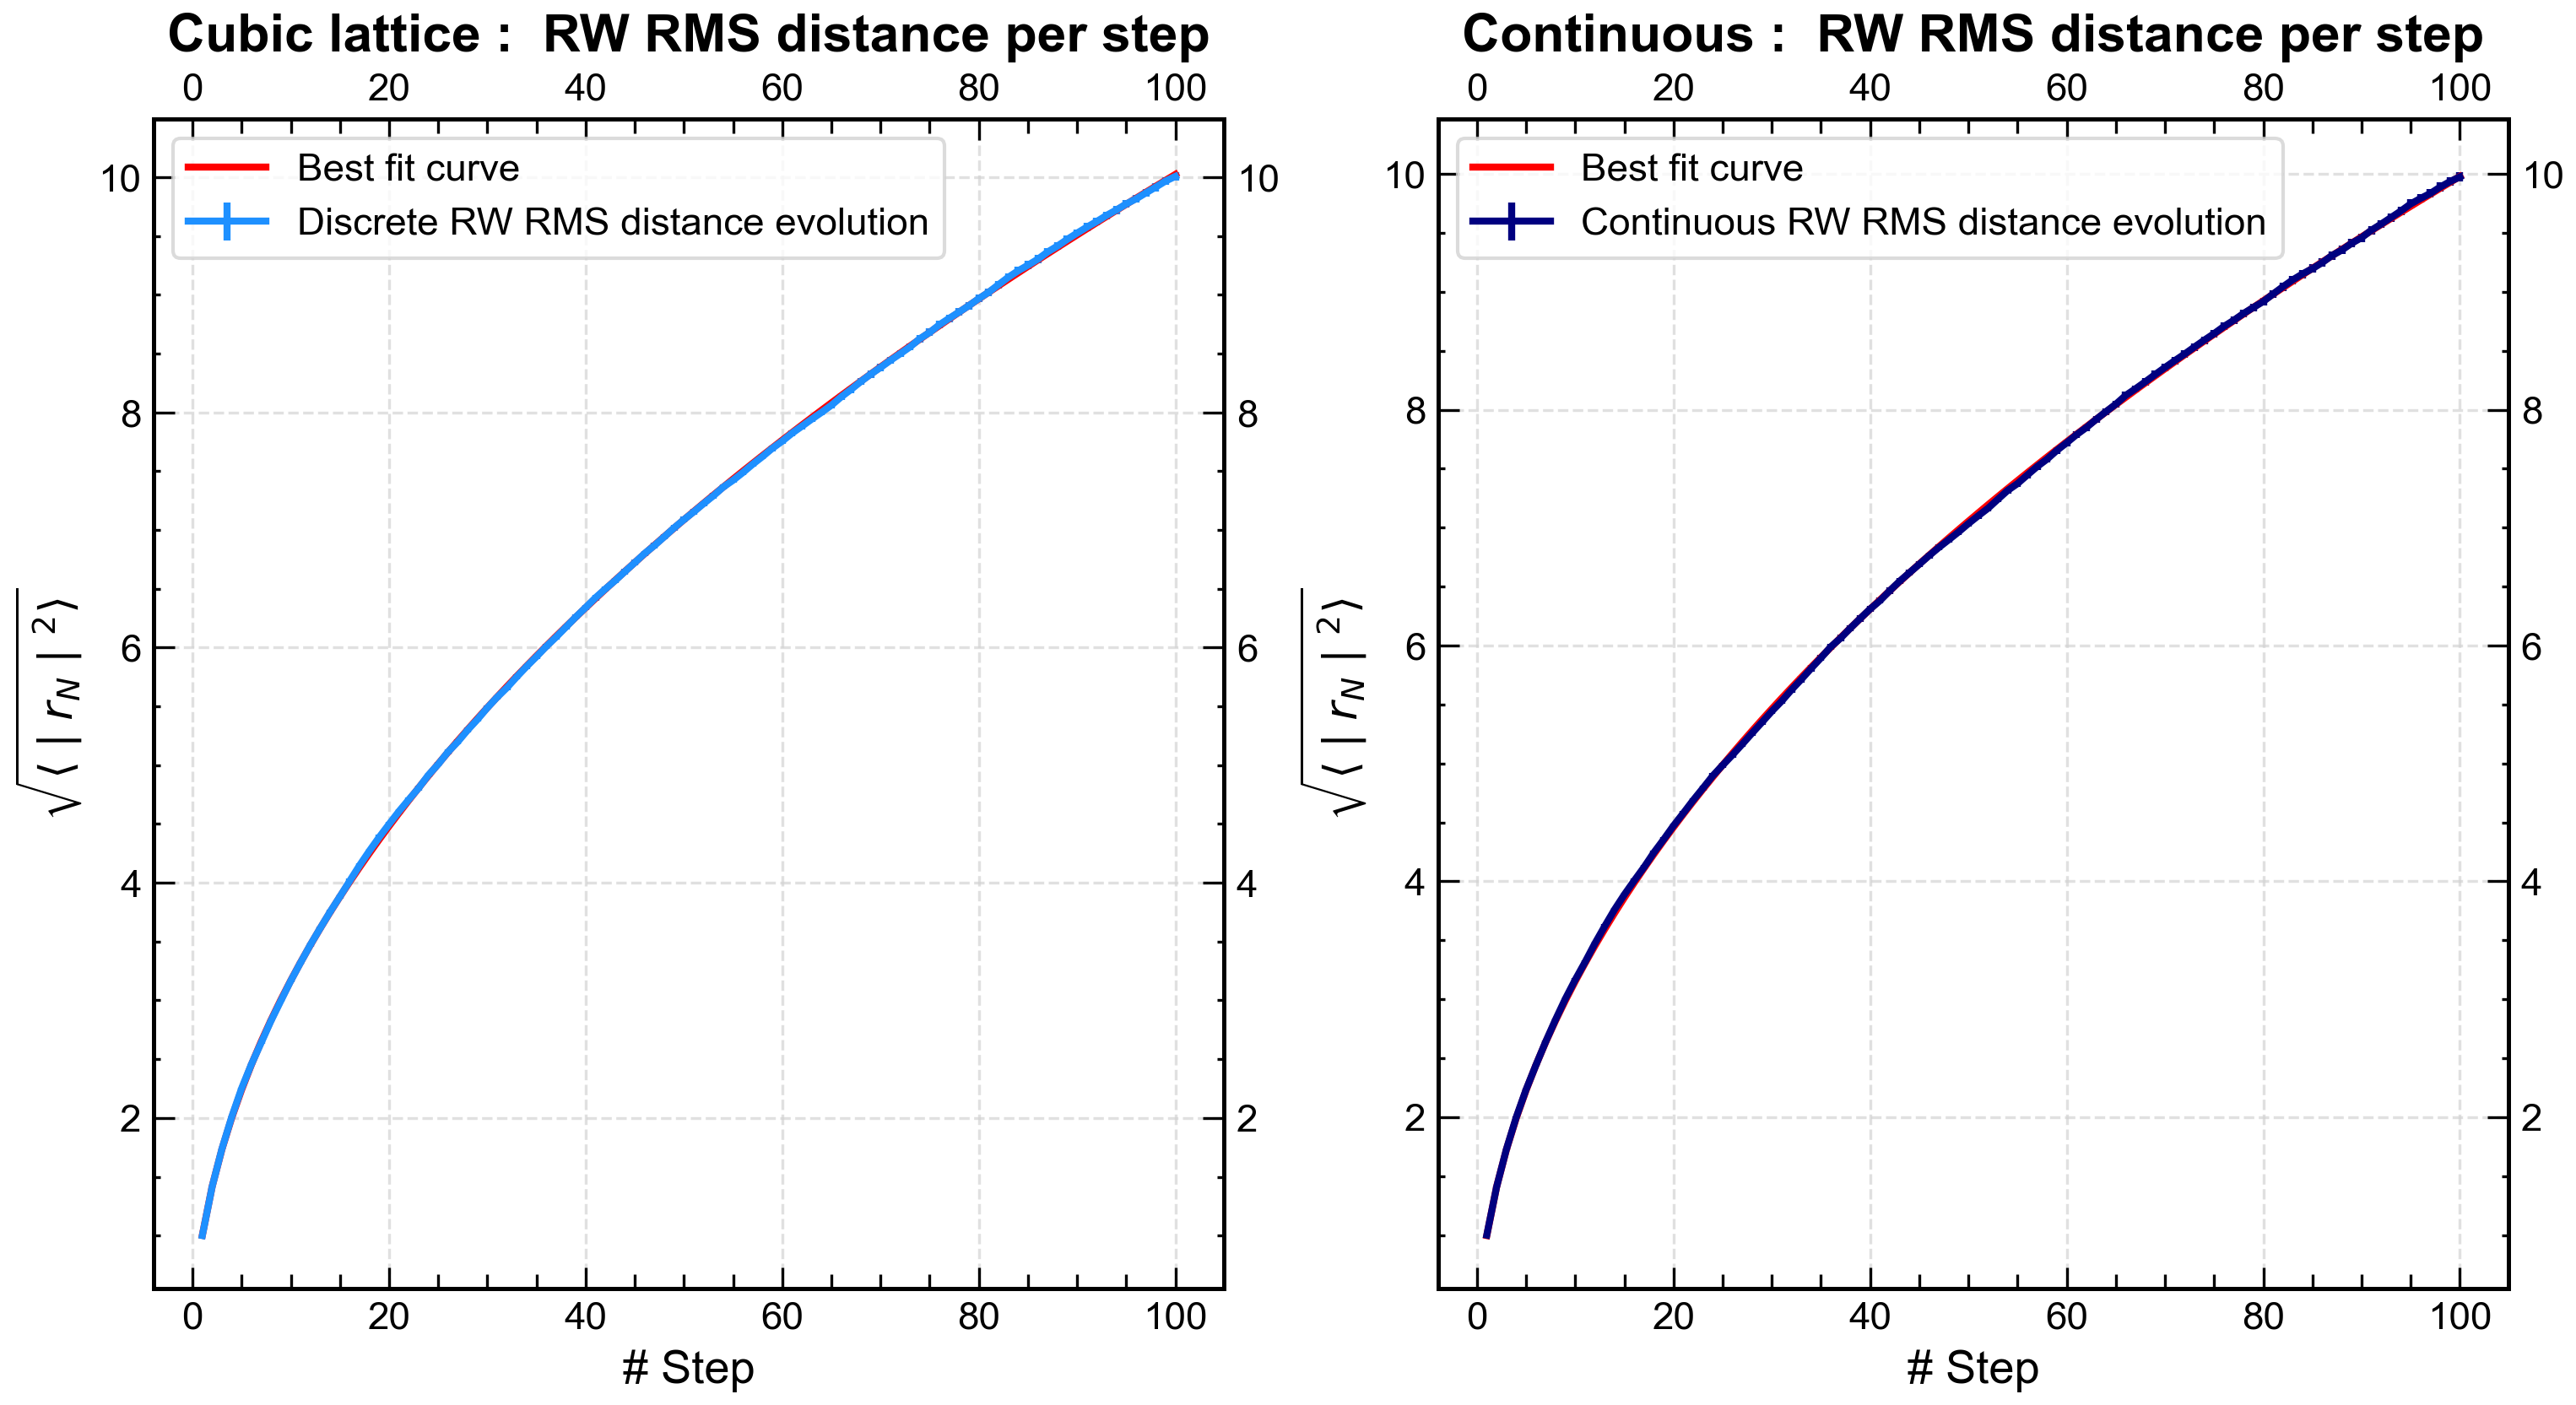

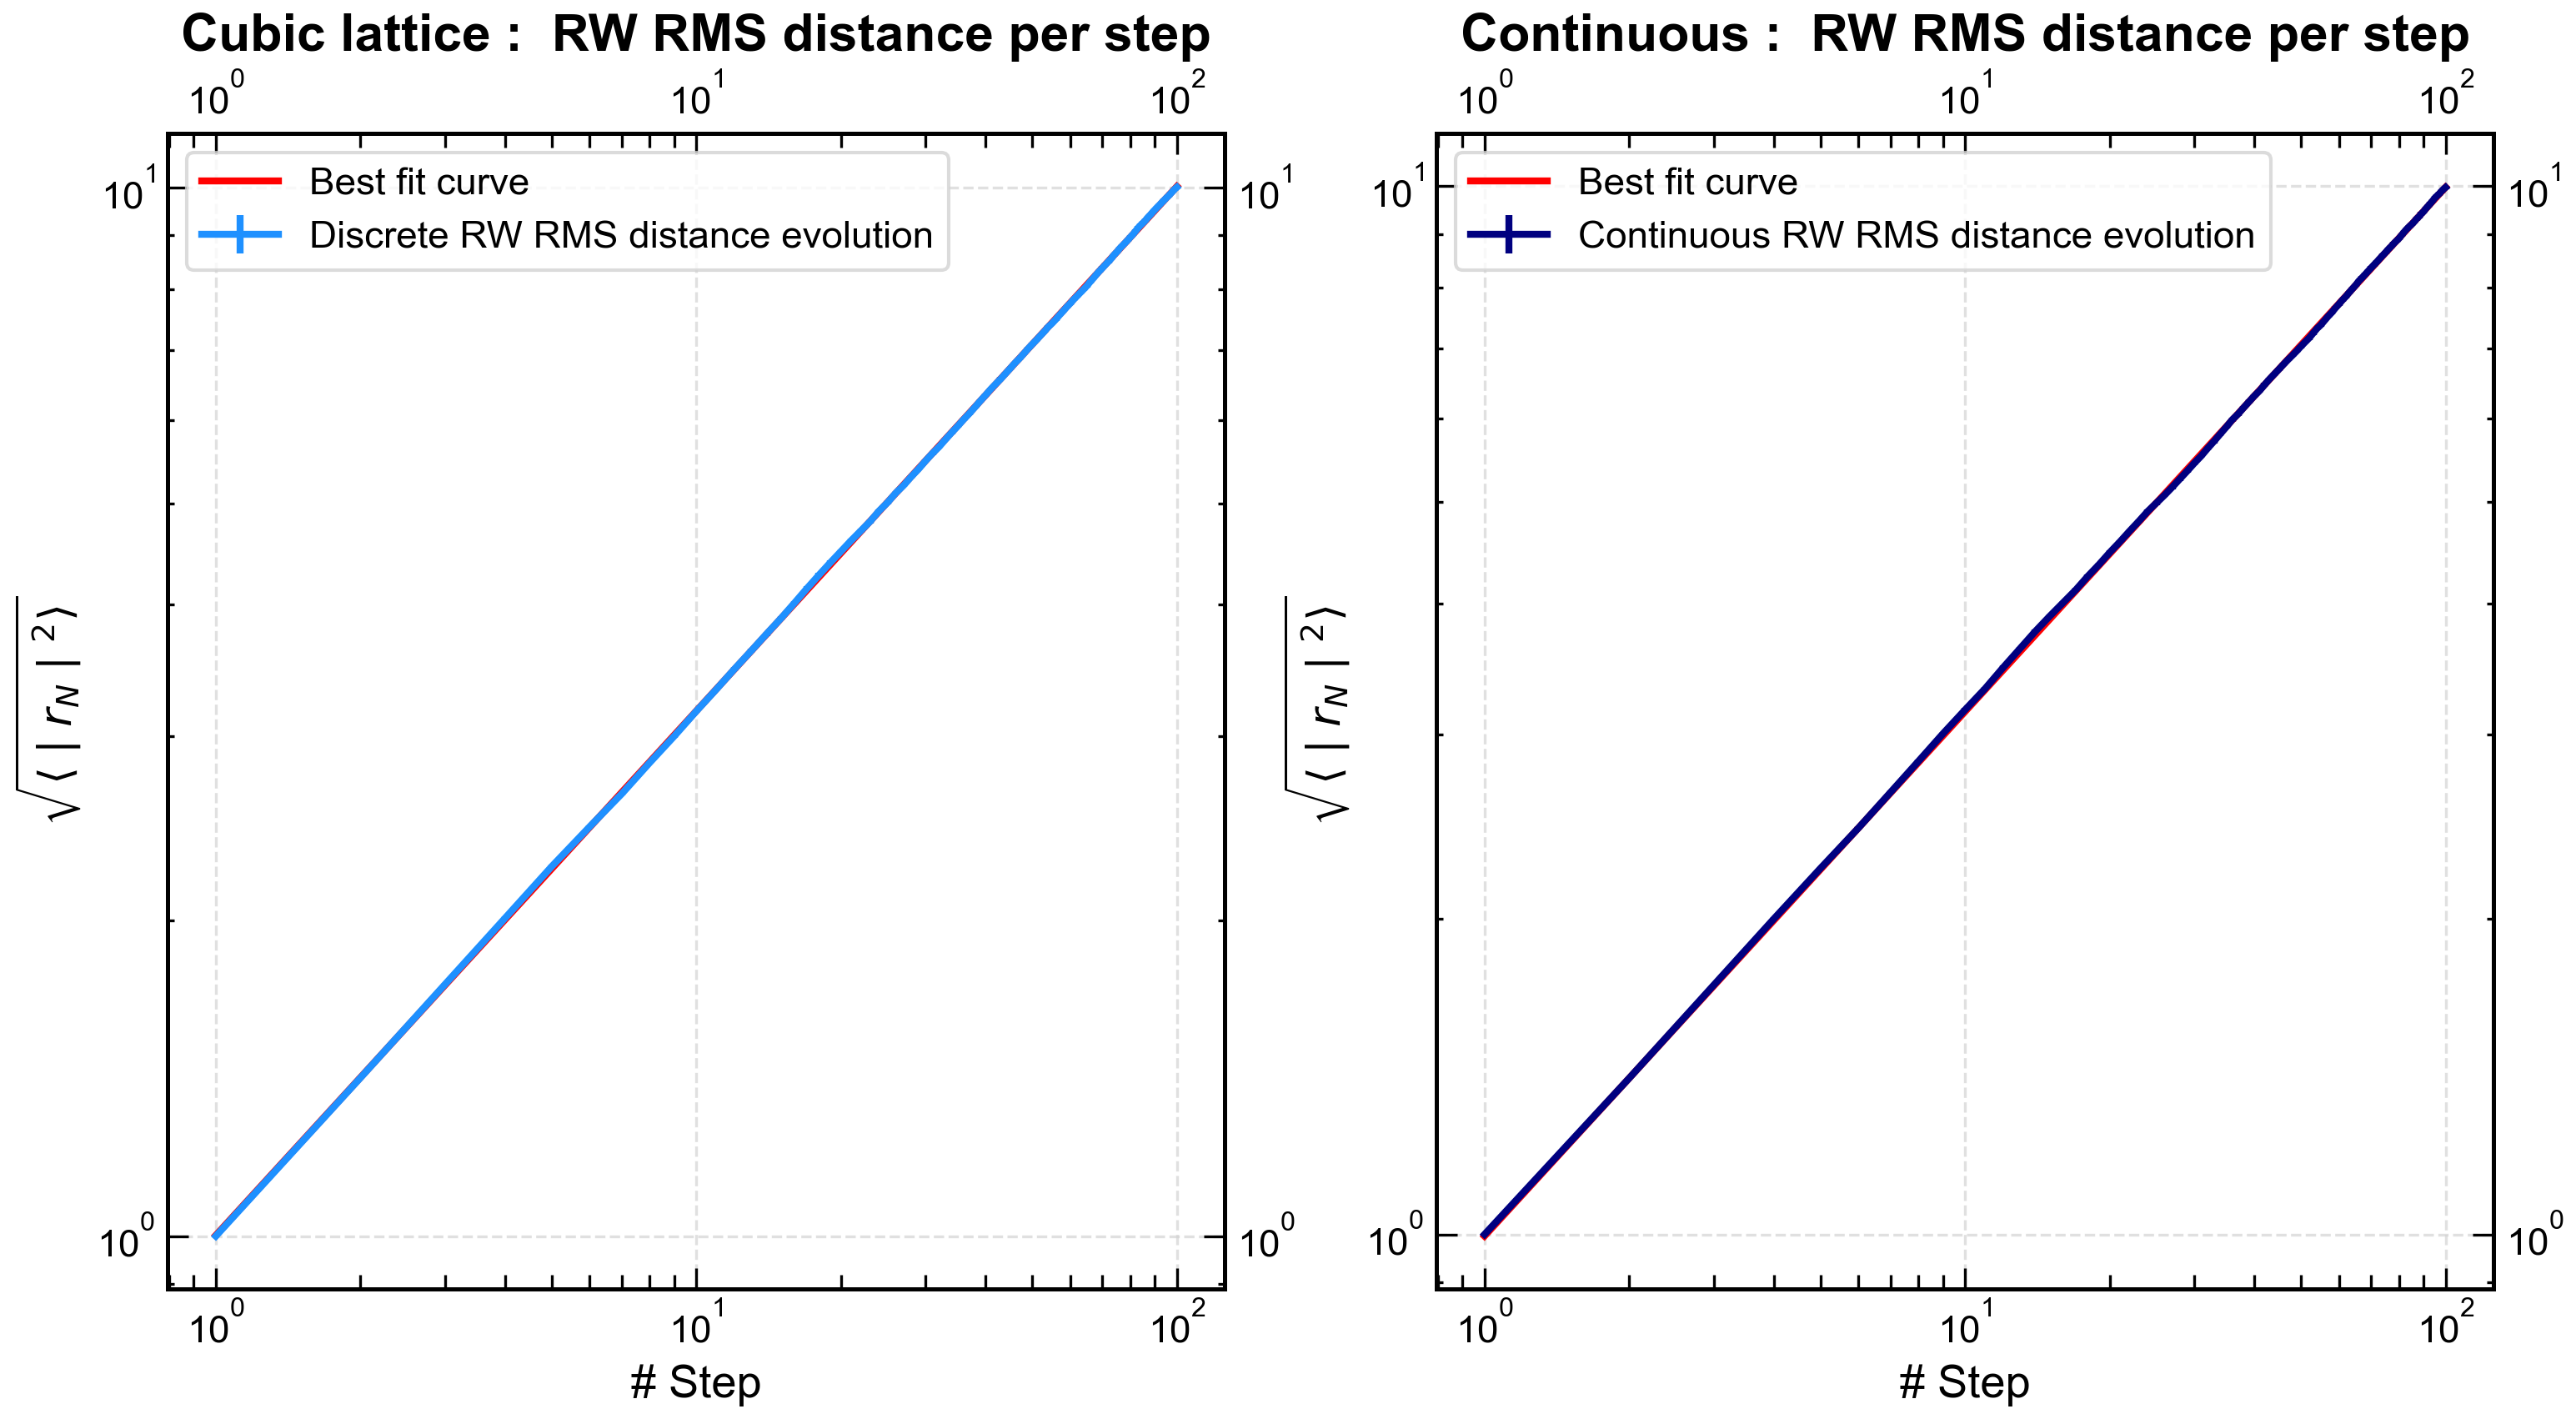

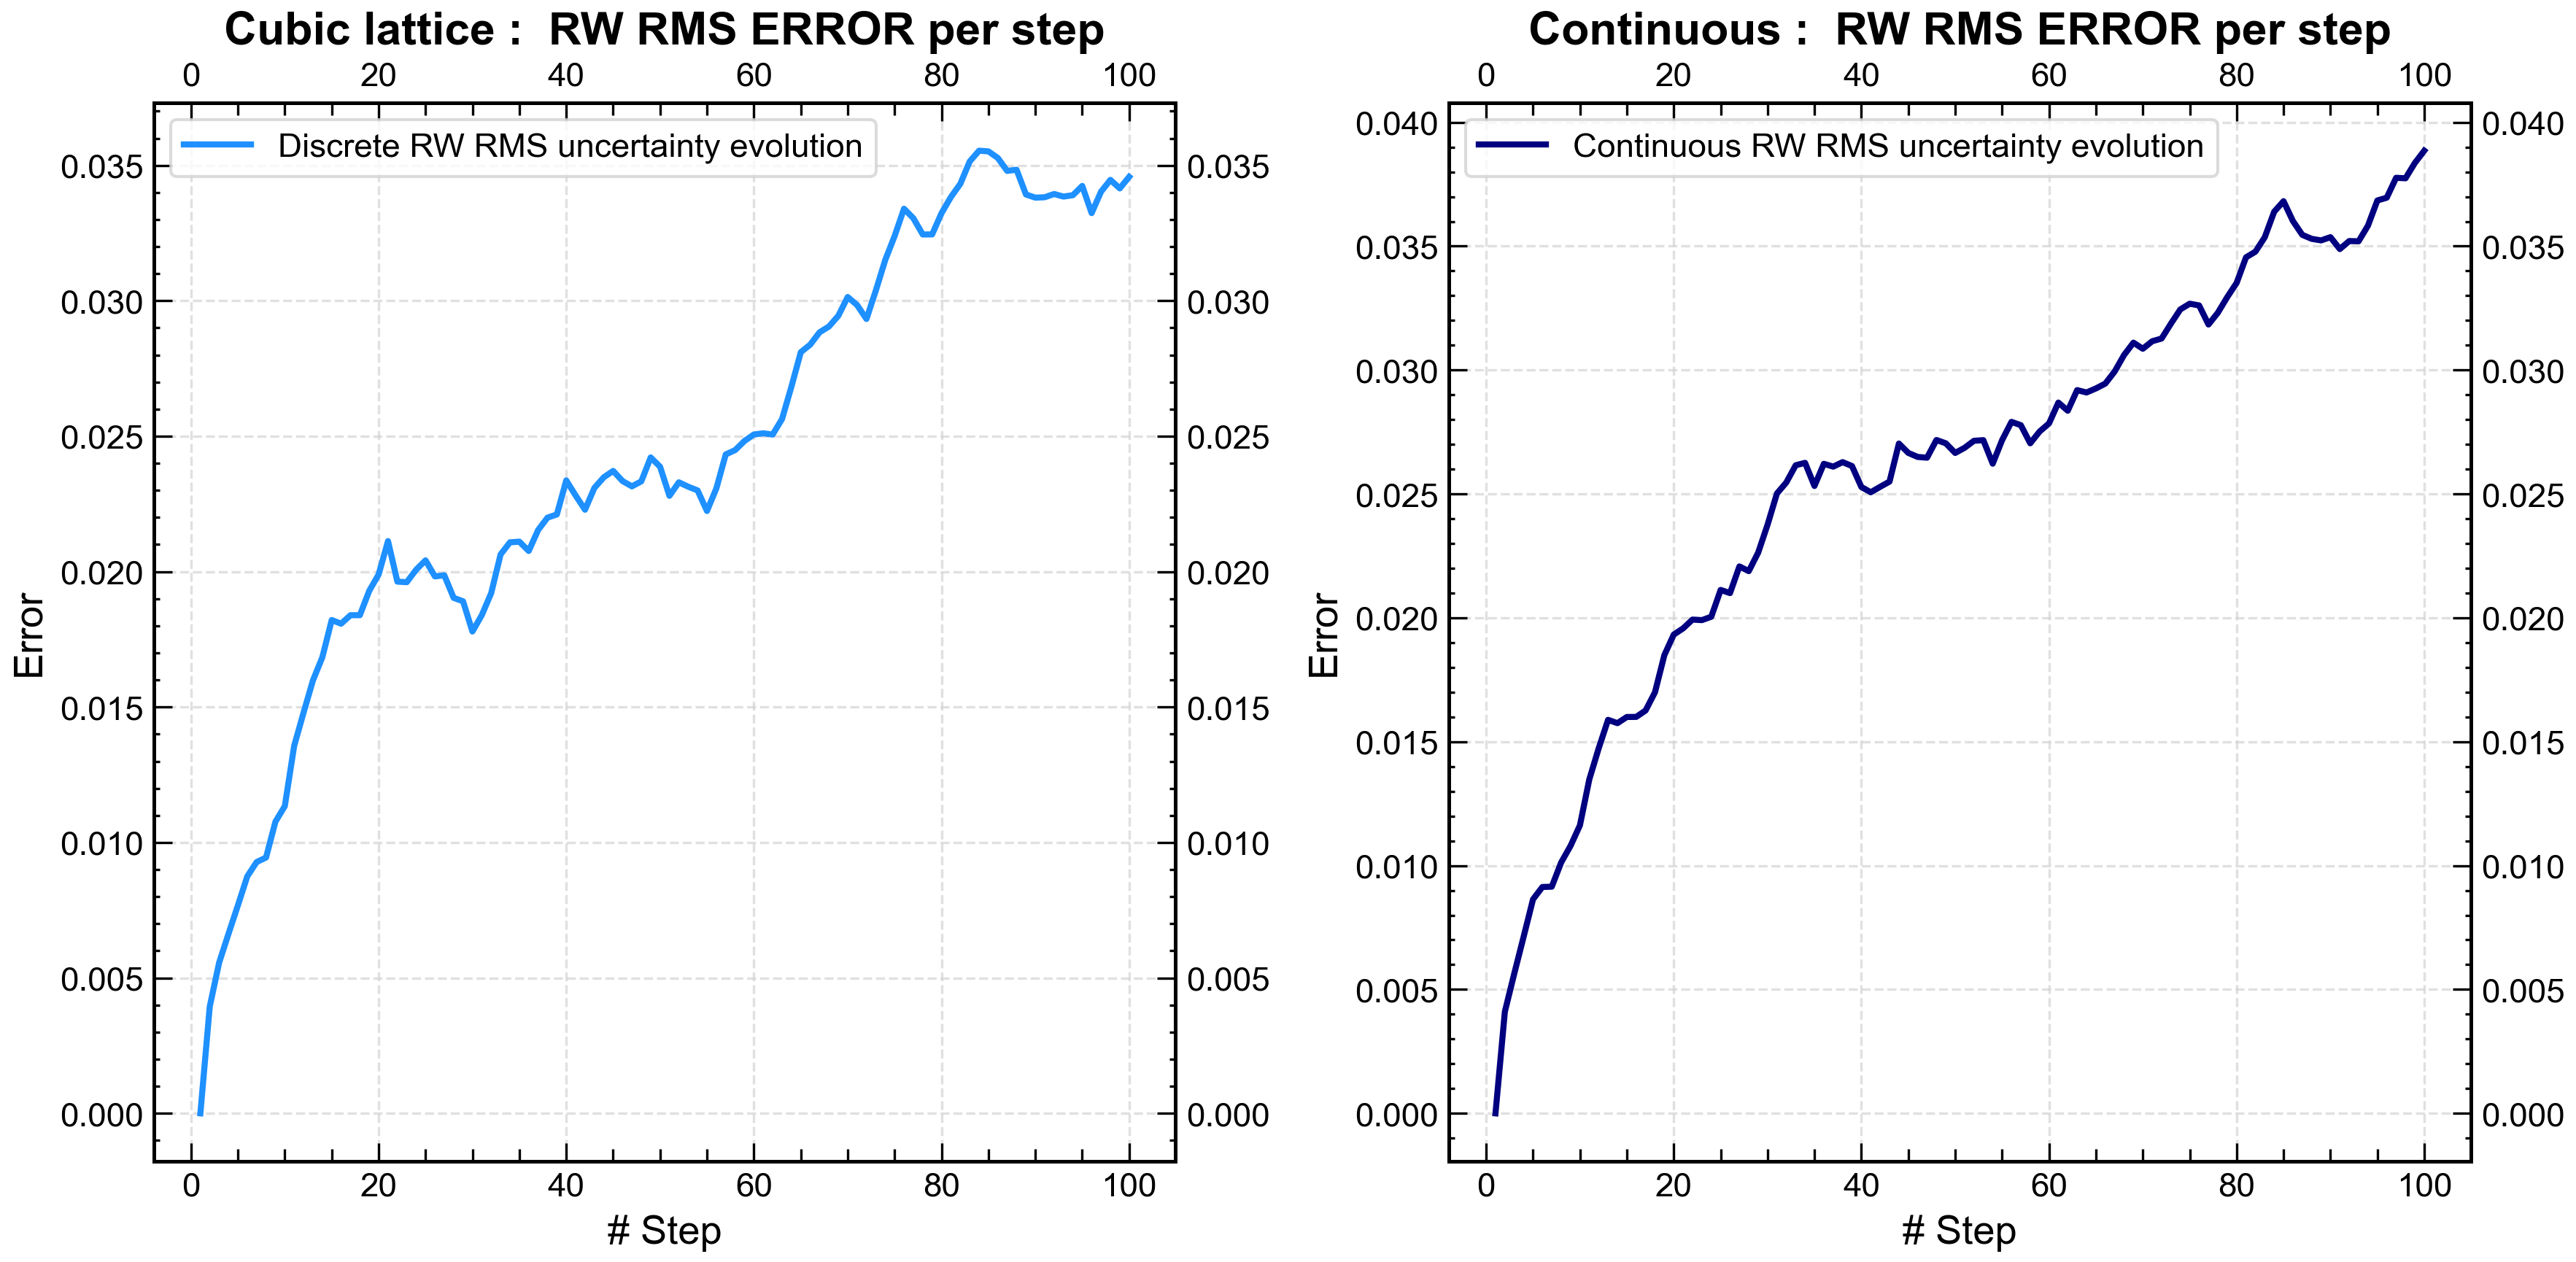

Cubic lattice : 
optimized parameters "a" =  1.0018
parameter "a" uncertainty =  0.001
optimized parameters "b" =  0.5001
parameter "b" uncertainty =  0.0002
Continuous : 
optimized parameters "a" =  0.9963
parameter "a" uncertainty =  0.0014
optimized parameters "b" =  0.5003
parameter "b" uncertainty =  0.0003


In [3]:
from scipy.optimize import curve_fit

# Define fit function
def fit_func(x, a, b) :
    return a * (x**b)

# X-fit interval
x_fit = np.arange(1, 101)

# Set up variables for the plots
directory = ["RW_DISCRETE", "RW_CONTINUOUS"]  # Directories for data files
color = ["dodgerblue", "navy"]  # Colors for the plots
title = ["Cubic lattice : ", "Continuous : "]  # Titles for the plots
label = ["Discrete", "Continuous"]  # Labels for the plots
fig, axs = plt.subplots(1, 2, figsize=(12, 6))  # Create a figure with 2 subplots (linear plot)
fig2, axs2 = plt.subplots(1, 2, figsize = (12, 6)) # Create a figure with 2 subplots (log-log plot)
fig3, axs3 = plt.subplots(1, 2, figsize = (12, 6)) # Create a figure with 2 subplots (error plot)
fit_parameters = []
sigma_fit_parameters = []

# Loop over the two datasets
for i in range(2):
    # Load data from the specified file, unpacking into step, dist, and err
    step, dist, err = np.loadtxt("es_2.2/" + directory[i] + "/OUTPUT/sqrt_mean_distance2_per_step.dat", unpack=True)
    step = step + 1  # Increment step by 1 to avoid zero in the plot

    # Plot the data with error bars
    axs[i].errorbar(step, dist, yerr = err, color = color[i], label = label[i] + " RW RMS distance evolution")
    axs2[i].errorbar(step, dist, yerr = err, color = color[i], label = label[i] + " RW RMS distance evolution")
    axs3[i].plot(step, err, color = color[i], label = label[i] + " RW RMS uncertainty evolution")
    
    # Fit the model to the data
    popt, pcov = curve_fit(fit_func, step, dist)  # Optimize the parameters of the fitting function
    fit_parameters.append(popt[0])
    fit_parameters.append(popt[1])
    sigma_fit_parameters.append(np.sqrt(pcov[0][0]))
    sigma_fit_parameters.append(np.sqrt(pcov[1][1]))

    # Calculate the fitted values using the optimized parameters
    y_fit = fit_func(x_fit, popt[0], popt[1])
    
    # Plot the best fit curve
    axs[i].plot(x_fit, y_fit, color = "red", label = "Best fit curve")
    axs2[i].plot(x_fit, y_fit, color = "red", label = "Best fit curve")
    
    # Set the title and labels for the subplot
    axs[i].set_title(title[i] + " RW RMS distance per step")
    axs[i].set_xlabel("# Step")  # X-axis label
    axs[i].set_ylabel(r"$\sqrt{\langle \mid r_{N}\mid ^2 \rangle}$")  # Y-axis label
    # axs[i].grid(True, ls = "--")  # Enable grid with linestyle dashed
    axs[i].legend()  # Add a legend

    axs2[i].set_title(title[i] + " RW RMS distance per step")
    axs2[i].set_xlabel("# Step")  # X-axis label
    axs2[i].set_xscale("log") # X-axis log scale
    axs2[i].set_ylabel(r"$\sqrt{\langle \mid r_{N}\mid ^2 \rangle}$")  # Y-axis label
    axs2[i].set_yscale("log") # Y-axis log scale
    # axs2[i].grid(True, ls = "--")  # Enable grid with linestyle dashed
    axs2[i].legend(loc = "best")  # Add a legend

    axs3[i].set_title(title[i] + " RW RMS ERROR per step")
    axs3[i].set_xlabel("# Step")  # X-axis label
    axs3[i].set_ylabel("Error")  # Y-axis label
    # axs3[i].grid(True, ls = "--")  # Enable grid with linestyle dashed
    axs3[i].legend(loc = "best")  # Add a legend

# Adjust layout to prevent overlap
plt.tight_layout()
plt.subplots_adjust()

# Show the plot
plt.show()

fig.savefig("es_2.2/plot/RMS_VS_STEP.png")
fig2.savefig("es_2.2/plot/RMS_VS_STEP_log_log.png")
fig3.savefig("es_2.2/plot/RMS_ERROR_VS_STEP.png")

for i in range(2):
    print(title[i])  # Print the title for the current dataset
    print("optimized parameters \"a\" = ", np.round(fit_parameters[2*i+0], 4))  # Print the optimized parameter a
    print("parameter \"a\" uncertainty = ", np.round(sigma_fit_parameters[2*i+0], 4))  # Print the uncertainty of the parameter a
    print("optimized parameters \"b\" = ", np.round(fit_parameters[2*i+1], 4))  # Print the optimized parameter b
    print("parameter \"b\" uncertainty = ", np.round(sigma_fit_parameters[2*i+1], 4))  # Print the uncertainty of the parameter b)


<h4>Conclusion</h4>

The plots above show how the RMS distance from starting point $(x,y,z) = (0,0,0)$ goes as the number of RW steps increase. I have also plotted a best fit curve for both dataset (in red) which should describe a diffusive process.

The simulation curve is compatible with a diffusive process both for the cubic lattice and the continuum. We can also appreciate the power low described by the dataset in the log-log plot, where the diffusion process is described by :
$$Y = A + bX,$$
where $Y = \mathrm{log}(\langle r^2_N \rangle)$ , $A = \mathrm{log}(k)$, $b$ is the power law coefficient (should be equal to $\frac{1}{2}$) and $X = \mathrm{log}(N)$.

Performing a fit using as fit function:
$$y = k \cdot x^b$$
we obtain :
- $k = 1.0018 \pm 0.0010$ and $b = 0.5001 \pm 0.0002$ for the cubic lattice RW;
- $k = 1.0163 \pm 0.0013$ and $b = 0.4955 \pm 0.0003$ for the continuum RW.

Both these results are compatible with a function like $f(N)=k\sqrt{N}$ since the exponential value $b \approx \frac{1}{2}$.

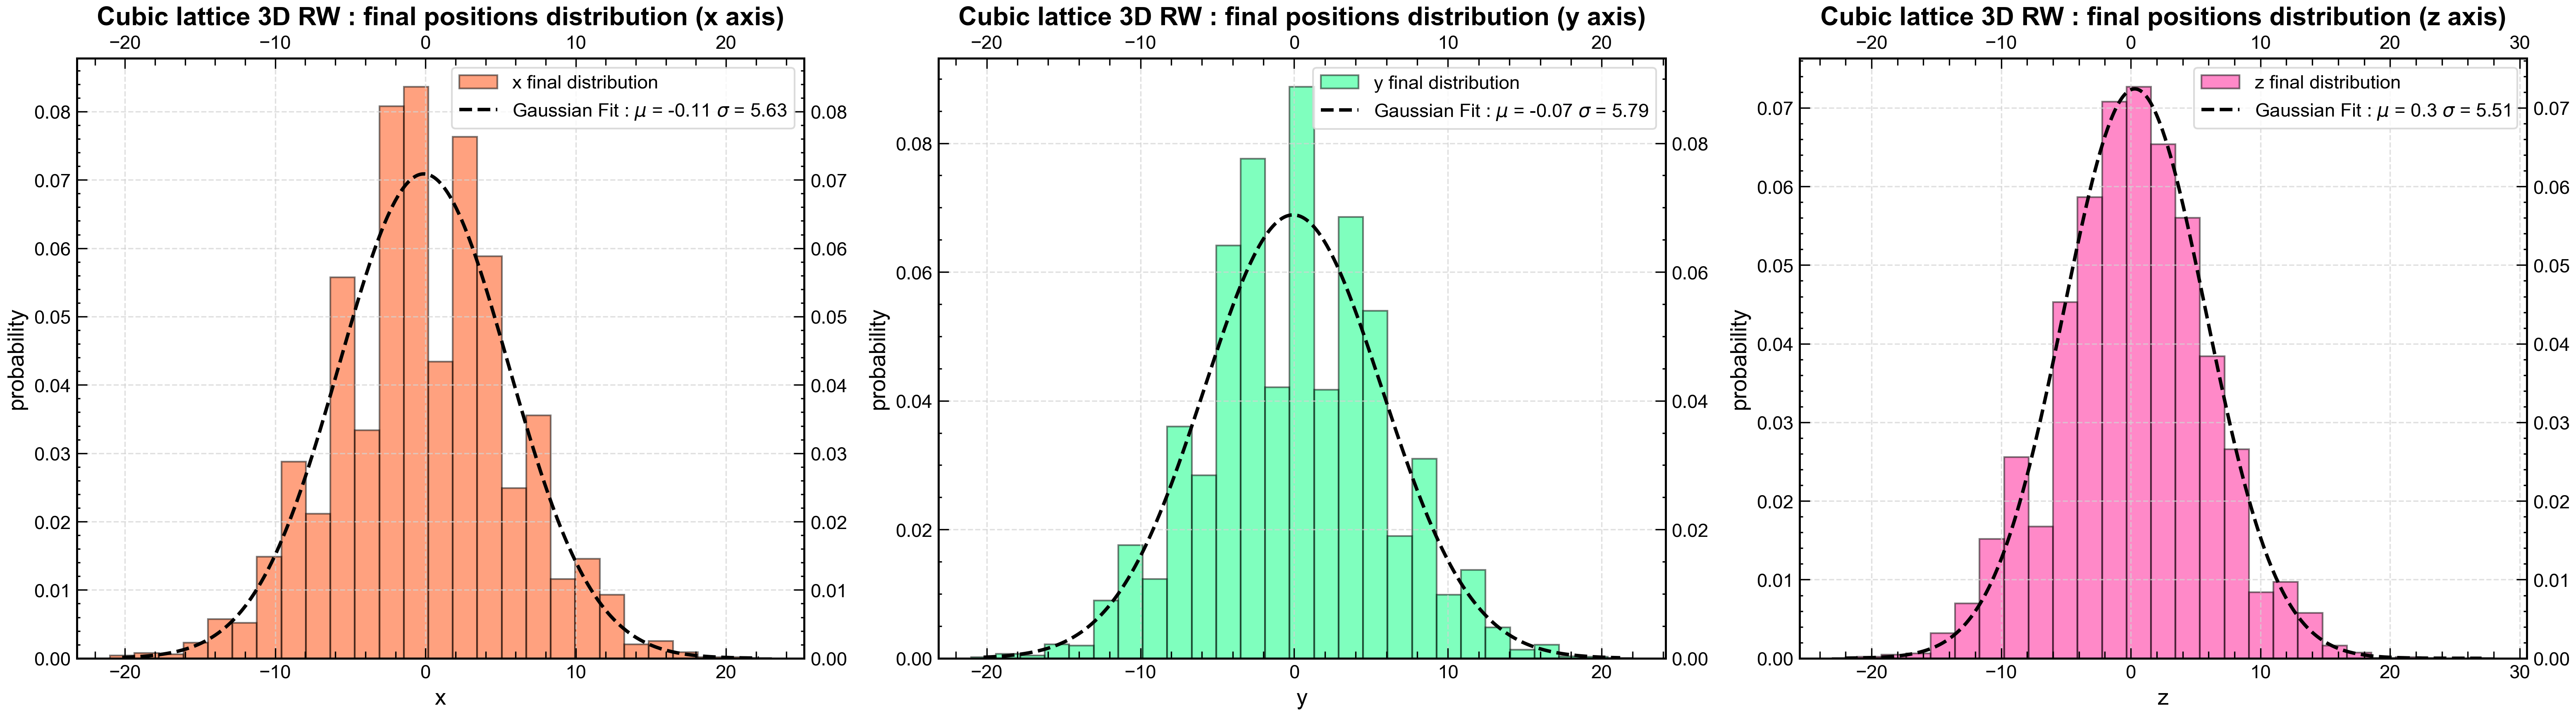

Cubic lattice 3D RW : 
Distribution fit parameters value :
	x : mu = -0.11 ± 0.45 distance from expected value in sigma units : 0.24
            sigma = 5.63 ± 0.37 distance from expected value in sigma units : 0.39
	y : mu = -0.07 ± 0.5 distance from expected value in sigma units : 0.14
            sigma = 5.79 ± 0.41 distance from expected value in sigma units : 0.05
	z : mu = 0.3 ± 0.17 distance from expected value in sigma units : 1.73
            sigma = 5.51 ± 0.14 distance from expected value in sigma units : 1.85


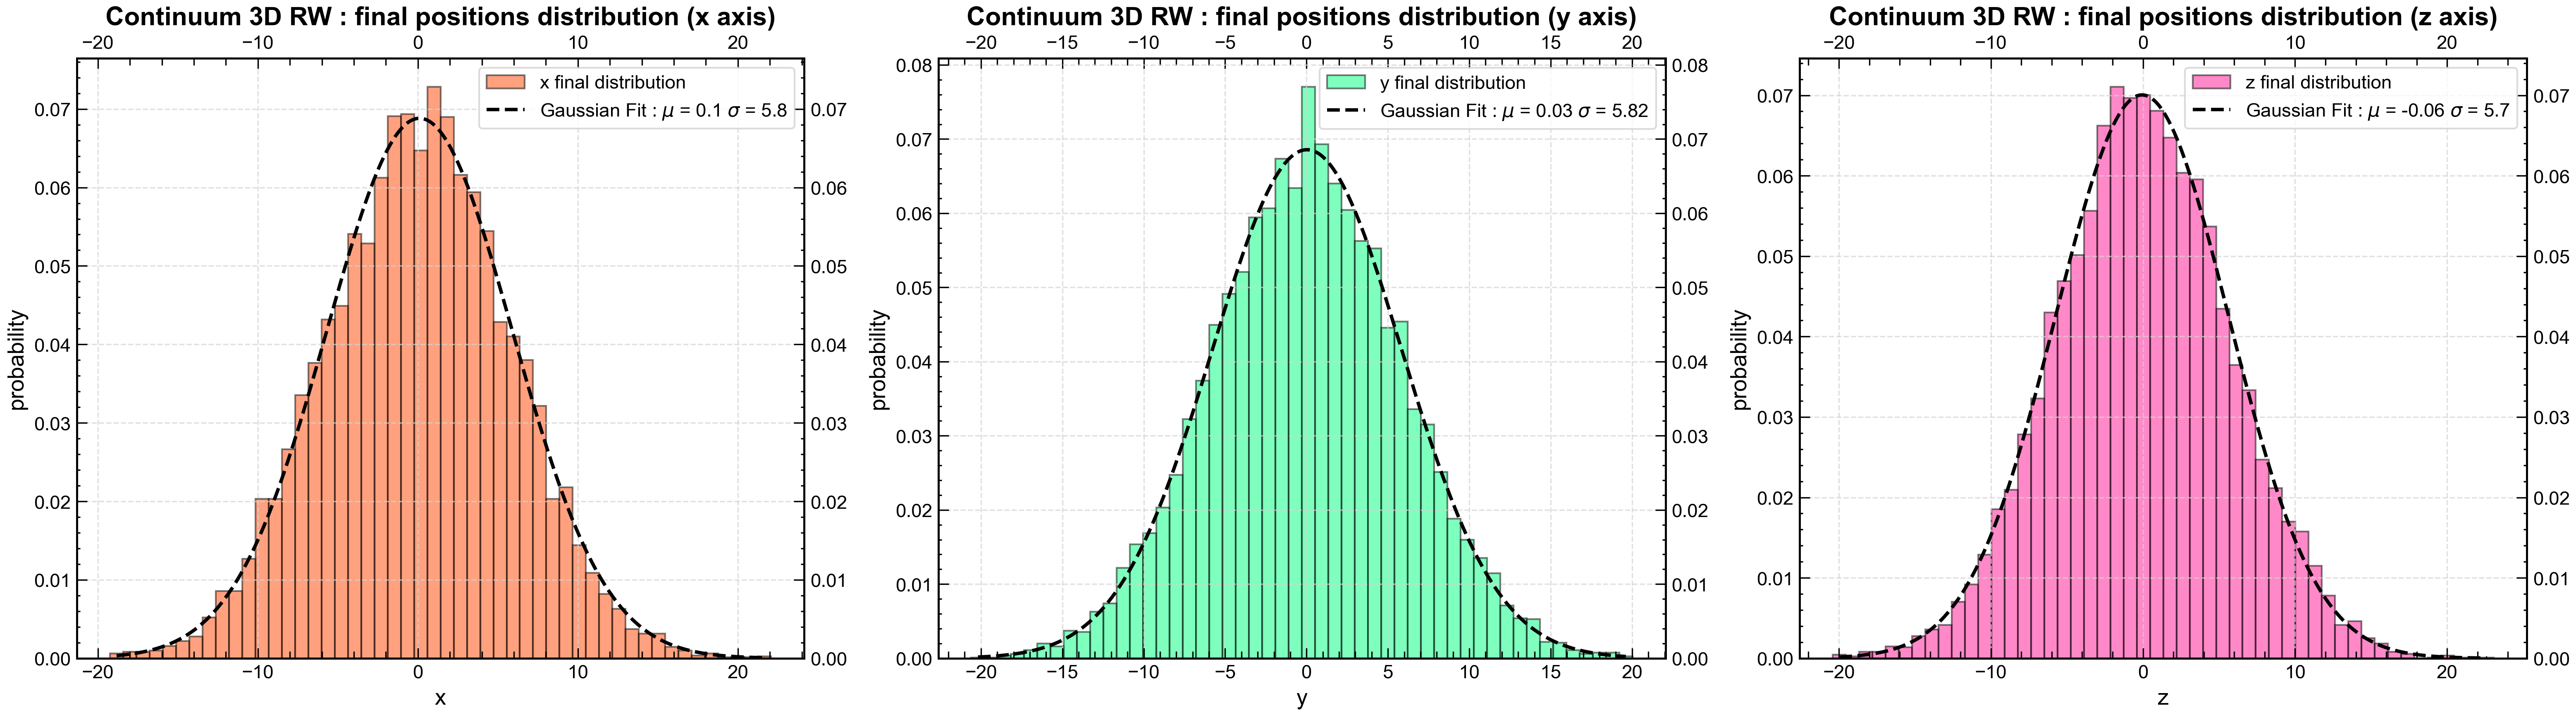

Continuum 3D RW : 
Distribution fit parameters value :
	x : mu = 0.1 ± 0.07 distance from expected value in sigma units : 1.47
            sigma = 5.8 ± 0.06 distance from expected value in sigma units : 0.42
	y : mu = 0.03 ± 0.06 distance from expected value in sigma units : 0.45
            sigma = 5.82 ± 0.05 distance from expected value in sigma units : 0.86
	z : mu = -0.06 ± 0.05 distance from expected value in sigma units : 1.2
            sigma = 5.7 ± 0.04 distance from expected value in sigma units : 1.92


In [4]:
# Define the Gaussian Probability Density Function (PDF)
def gaussian_pdf(x, mean, stddev):
    # Ensure stddev is positive to avoid mathematical errors (e.g., division by zero or log of non-positive)
    if stddev <= 0:
        return np.zeros_like(x)
    return (1 / (stddev * np.sqrt(2 * np.pi))) * np.exp(-((x - mean) ** 2) / (2 * stddev ** 2))


# path to file for random walk data
file_path = ["es_2.2/RW_DISCRETE/OUTPUT/last_position.dat", "es_2.2/RW_CONTINUOUS/OUTPUT/last_position.dat"]
RW_type = ["Cubic lattice 3D RW : ", "Continuum 3D RW : "]
# Colors for the histograms (one for each of x, y, z distributions)
color = ["orangered", "springgreen", "deeppink"]

# RW parameters
steps = 100
time_step = 1
lattice_size = 1
dim = 3
D = (lattice_size**2)/(2*dim*time_step) # since we are considering a 3D RW, diffusiveness constant has to be expressed also as function of system dimension
exp_mean = 0.0
exp_std_dev = np.sqrt(2*D*steps*time_step)

# list for fit parameters
means = []
means_error = []
std_devs = []
std_devs_error = []

# Loop through the two types of Random Walks (Discrete and Continuous)
for i in range(2):
    # Load final position data (X, Y, Z coordinates) from the specified file
    X, Y, Z = np.loadtxt(file_path[i], usecols=(1, 2, 3), unpack=True)

    # Labels for the x, y, z axes of the plots
    axs_label = ["x", "y", "z"]
    # Titles for the individual subplots
    plt_title = ["final positions distribution (x axis)", "final positions distribution (y axis)", "final positions distribution (z axis)"]

    # Create a figure with 1 row and 3 subplots for displaying x, y, and z distributions
    # fig: The overall figure object
    # axs: A NumPy array containing the individual subplot (Axes) objects
    # For a 1x3 layout, axs will be a 1D array, e.g., [ax0, ax1, ax2]
    fig, axs = plt.subplots(1, 3, figsize=(21, 6))

    # Flatten the 'axs' array for easier iteration
    # This converts the array of Axes objects into a 1D iterable regardless of the initial subplot grid dimensions (e.g., from [[ax0, ax1, ax2]] to [ax0, ax1, ax2])
    # This simplifies accessing each subplot in a single loop
    axs_flat = axs.flatten()

    # Data arrays to be plotted for x, y, and z distributions
    data_to_plot = [X, Y, Z]

    # Iterate through the flattened array of subplot axes enumerate(axs_flat) provides both the index (j) and the current Axes object (ax) in each iteration
    # 'j' will be 0, 1, 2, corresponding to the current subplot's index and used to access elements from `axs_label`, `plt_title`, and `data_to_plot`
    # 'ax' is the actual matplotlib Axes object for the current subplot where plotting commands (hist, plot, set_title, etc.) are applied
    for j, ax in enumerate(axs_flat):
        # n: Array of histogram bin counts (normalized due to density=True)
        # bins: Array of bin edge values
        # patches: List of Patch objects (the histogram bars)
        if(i==0):
            n, bins, patches = ax.hist(data_to_plot[j], bins=27, density=True, color=color[j], edgecolor="black", alpha=0.5, label=axs_label[j] + " final distribution")
        else:
            n, bins, patches = ax.hist(data_to_plot[j], bins=50, density=True, color=color[j], edgecolor="black", alpha=0.5, label=axs_label[j] + " final distribution")
        

        # Calculate the center of each bin. These will be the x-values for our curve fitting
        bin_centers = (bins[:-1] + bins[1:]) / 2

        try:
            # Perform the curve fitting using scipy.optimize.curve_fit
            # gaussian_pdf: The function to fit
            # bin_centers: The x-data points for fitting
            # n: The y-data points (normalized counts from the histogram) for fitting
            # popt: Array containing the optimal values for the fitted parameters (mean, stddev)
            # pcov: 2D array representing the estimated covariance of popt
            popt, pcov = curve_fit(gaussian_pdf, bin_centers, n)

            # Extract the fitted parameters from popt
            fitted_mean, fitted_stddev = popt
            means.append(popt[0])
            means_error.append(np.sqrt(pcov[0][0]))
            std_devs.append(popt[1])
            std_devs_error.append(np.sqrt(pcov[1][1]))

            # Generate a list of x-values for plotting the fitted curve
            x_fit_data = np.linspace(bin_centers.min(), bin_centers.max(), 500)

            # Plot the fitted Gaussian curve
            ax.plot(x_fit_data, gaussian_pdf(x_fit_data, fitted_mean, fitted_stddev), color='black', linestyle='--', linewidth=2, label= r"Gaussian Fit : $\mu$ = " + str(round(fitted_mean, 2)) + r" $\sigma$ = " + str(round(fitted_stddev, 2)))
    
        except RuntimeError:
            # Handle cases where `curve_fit` might fail to converge (e.g., if data is not Gaussian-like enough)
            print("Warning: Could not fit Gaussian for" + str(RW_type[i]) + " " + str(axs_label[j]) + " distribution.")
            print("This might happen if the data is too sparse or not Gaussian in shape.")

        # Set the title for the current subplot
        ax.set_title(RW_type[i] + plt_title[j])
        # Set the X-axis label for the current subplot
        ax.set_xlabel(axs_label[j])
        # Set the Y-axis label for the current subplot
        ax.set_ylabel("probability")
        # Enable grid with a dashed linestyle for better readability
        # ax.grid(True, ls="--")
        # Display the legend, which now includes both the histogram label and the fit parameters
        ax.legend(loc="best")

        # Adjust subplot parameters for a tight layout to prevent labels/titles from overlapping
        plt.tight_layout()
        if i == 0:
            plt.savefig("es_2.2/plot/Cubic_lattice_RW_final_position_distribution.png")
        else:
            plt.savefig("es_2.2/plot/Continuous_RW_final_position_distribution.png")

    
    # Display the figure
    plt.show()
    # Output data
    print(RW_type[i] + "\nDistribution fit parameters value :" + 
            "\n\tx : mu = " + str(round(means[3*i+0], 2)) + " ± " + str(round(means_error[3*i+0], 2)) + " distance from expected value in sigma units : " + str(round(abs(means[3*i+0]-exp_mean)/means_error[3*i+0], 2)) + "\n            sigma = " + str(round(std_devs[3*i+0], 2)) + " ± " + str(round(std_devs_error[3*i+0], 2)) + " distance from expected value in sigma units : " + str(round(abs(std_devs[3*i+0]-exp_std_dev)/std_devs_error[3*i+0], 2)) +
            "\n\ty : mu = " + str(round(means[3*i+1], 2)) + " ± " + str(round(means_error[3*i+1], 2)) + " distance from expected value in sigma units : " + str(round(abs(means[3*i+1]-exp_mean)/means_error[3*i+1], 2)) + "\n            sigma = " + str(round(std_devs[3*i+1], 2)) + " ± " + str(round(std_devs_error[3*i+1], 2)) + " distance from expected value in sigma units : " + str(round(abs(std_devs[3*i+1]-exp_std_dev)/std_devs_error[3*i+1], 2)) +
            "\n\tz : mu = " + str(round(means[3*i+2], 2)) + " ± " + str(round(means_error[3*i+2], 2)) + " distance from expected value in sigma units : " + str(round(abs(means[3*i+2]-exp_mean)/means_error[3*i+2], 2)) + "\n            sigma = " + str(round(std_devs[3*i+2], 2)) + " ± " + str(round(std_devs_error[3*i+2], 2)) + " distance from expected value in sigma units : " + str(round(abs(std_devs[3*i+2]-exp_std_dev)/std_devs_error[3*i+2], 2)) 
    )

Here we represent how coordinates of the last position of the RW are distributed. We have already said that the probability to find the walker at a certain time in a certain position in space is the solution of a PDE describing a diffusive process.

If we consider a 1D RW starting from $x(t=0)=0$, it has the form of a Normal Distribution where:
- mean value corresponds to the starting position ($\langle x(t) \rangle = 0$);
- variance is given by $\langle x^2(t) \rangle - \langle x(t) \rangle^2 = \langle x^2(t) \rangle = 2DN\tau$.

It is **crucial** to notice that one of the three coordinates of a 3D RW cannot be thought as a 1D RW. This because the probability to keep moving along just one of the three axis is different in the two Markov processes:
- $P(x \to x+a) = P(x \to x-a) = 0.5$ for 1D RW;
- $P(x \to x+a) = P(x \to x-a) = 0.16$ for 3D RW (we have $P(\text{no move along x axis}) = 1 - 2 \cdot 0.16 = 0.66$).

In this case the **diffusivity** for a RW along one of the three axis is given by:

$$D = \frac{a^2}{6\tau}$$

3 times smaller than the one defined for a step in a typical 1D RW.

Using this restriction on the 3D RW we can know see if the Gaussian fit parameters are statistically consistent with the Markov processes theory.

**Discrete RW**:
- $x(t = N\tau)$ is distributed as a Normal distribution with $\mu = -0.11 \pm 0.45$ and $\sigma = 5.63 \pm 0.37$. Mean value and standard deviation differs from the expected values respectively $0.24~\sigma$ and $0.39~\sigma$;
- $y(t = N\tau)$ is distributed as a Normal distribution with $\mu = -0.07 \pm 0.50$ and $\sigma = 5.719 \pm 0.41$. Mean value and standard deviation differs from the expected values respectively $0.14~\sigma$ and $0.05~\sigma$; 
- $z(t = N\tau)$ is distributed as a Normal distribution with $\mu = 0.30 \pm 0.17$ and $\sigma = 5.51 \pm 0.14$. Mean value and standard deviation differs from the expected values respectively $1.73~\sigma$ and $1.85~\sigma$. 

**Continuous RW**:
- $x(t = N\tau)$ is distributed as a Normal distribution with $\mu = -0.02 \pm 0.05$ and $\sigma = 5.77 \pm 0.04$. Mean value and standard deviation differs from the expected values respectively $0.39~\sigma$ and $0.05~\sigma$;
- $y(t = N\tau)$ is distributed as a Normal distribution with $\mu = -0.11 \pm 0.05$ and $\sigma = 5.81 \pm 0.04$. Mean value and standard deviation differs from the expected values respectively $2.17~\sigma$ and $0.95~\sigma$; 
- $z(t = N\tau)$ is distributed as a Normal distribution with $\mu = -0.10 \pm 0.06$ and $\sigma = 5.72 \pm 0.05$. Mean value and standard deviation differs from the expected values respectively $1.54~\sigma$ and $0.97~\sigma$.

All parameters are statistically consistent with the expected values. Discrete RW shows bigger uncertainties than the continuous one mainly because fitting discrete distribution is strongly influenced by the total number of bin used to create the histograms.

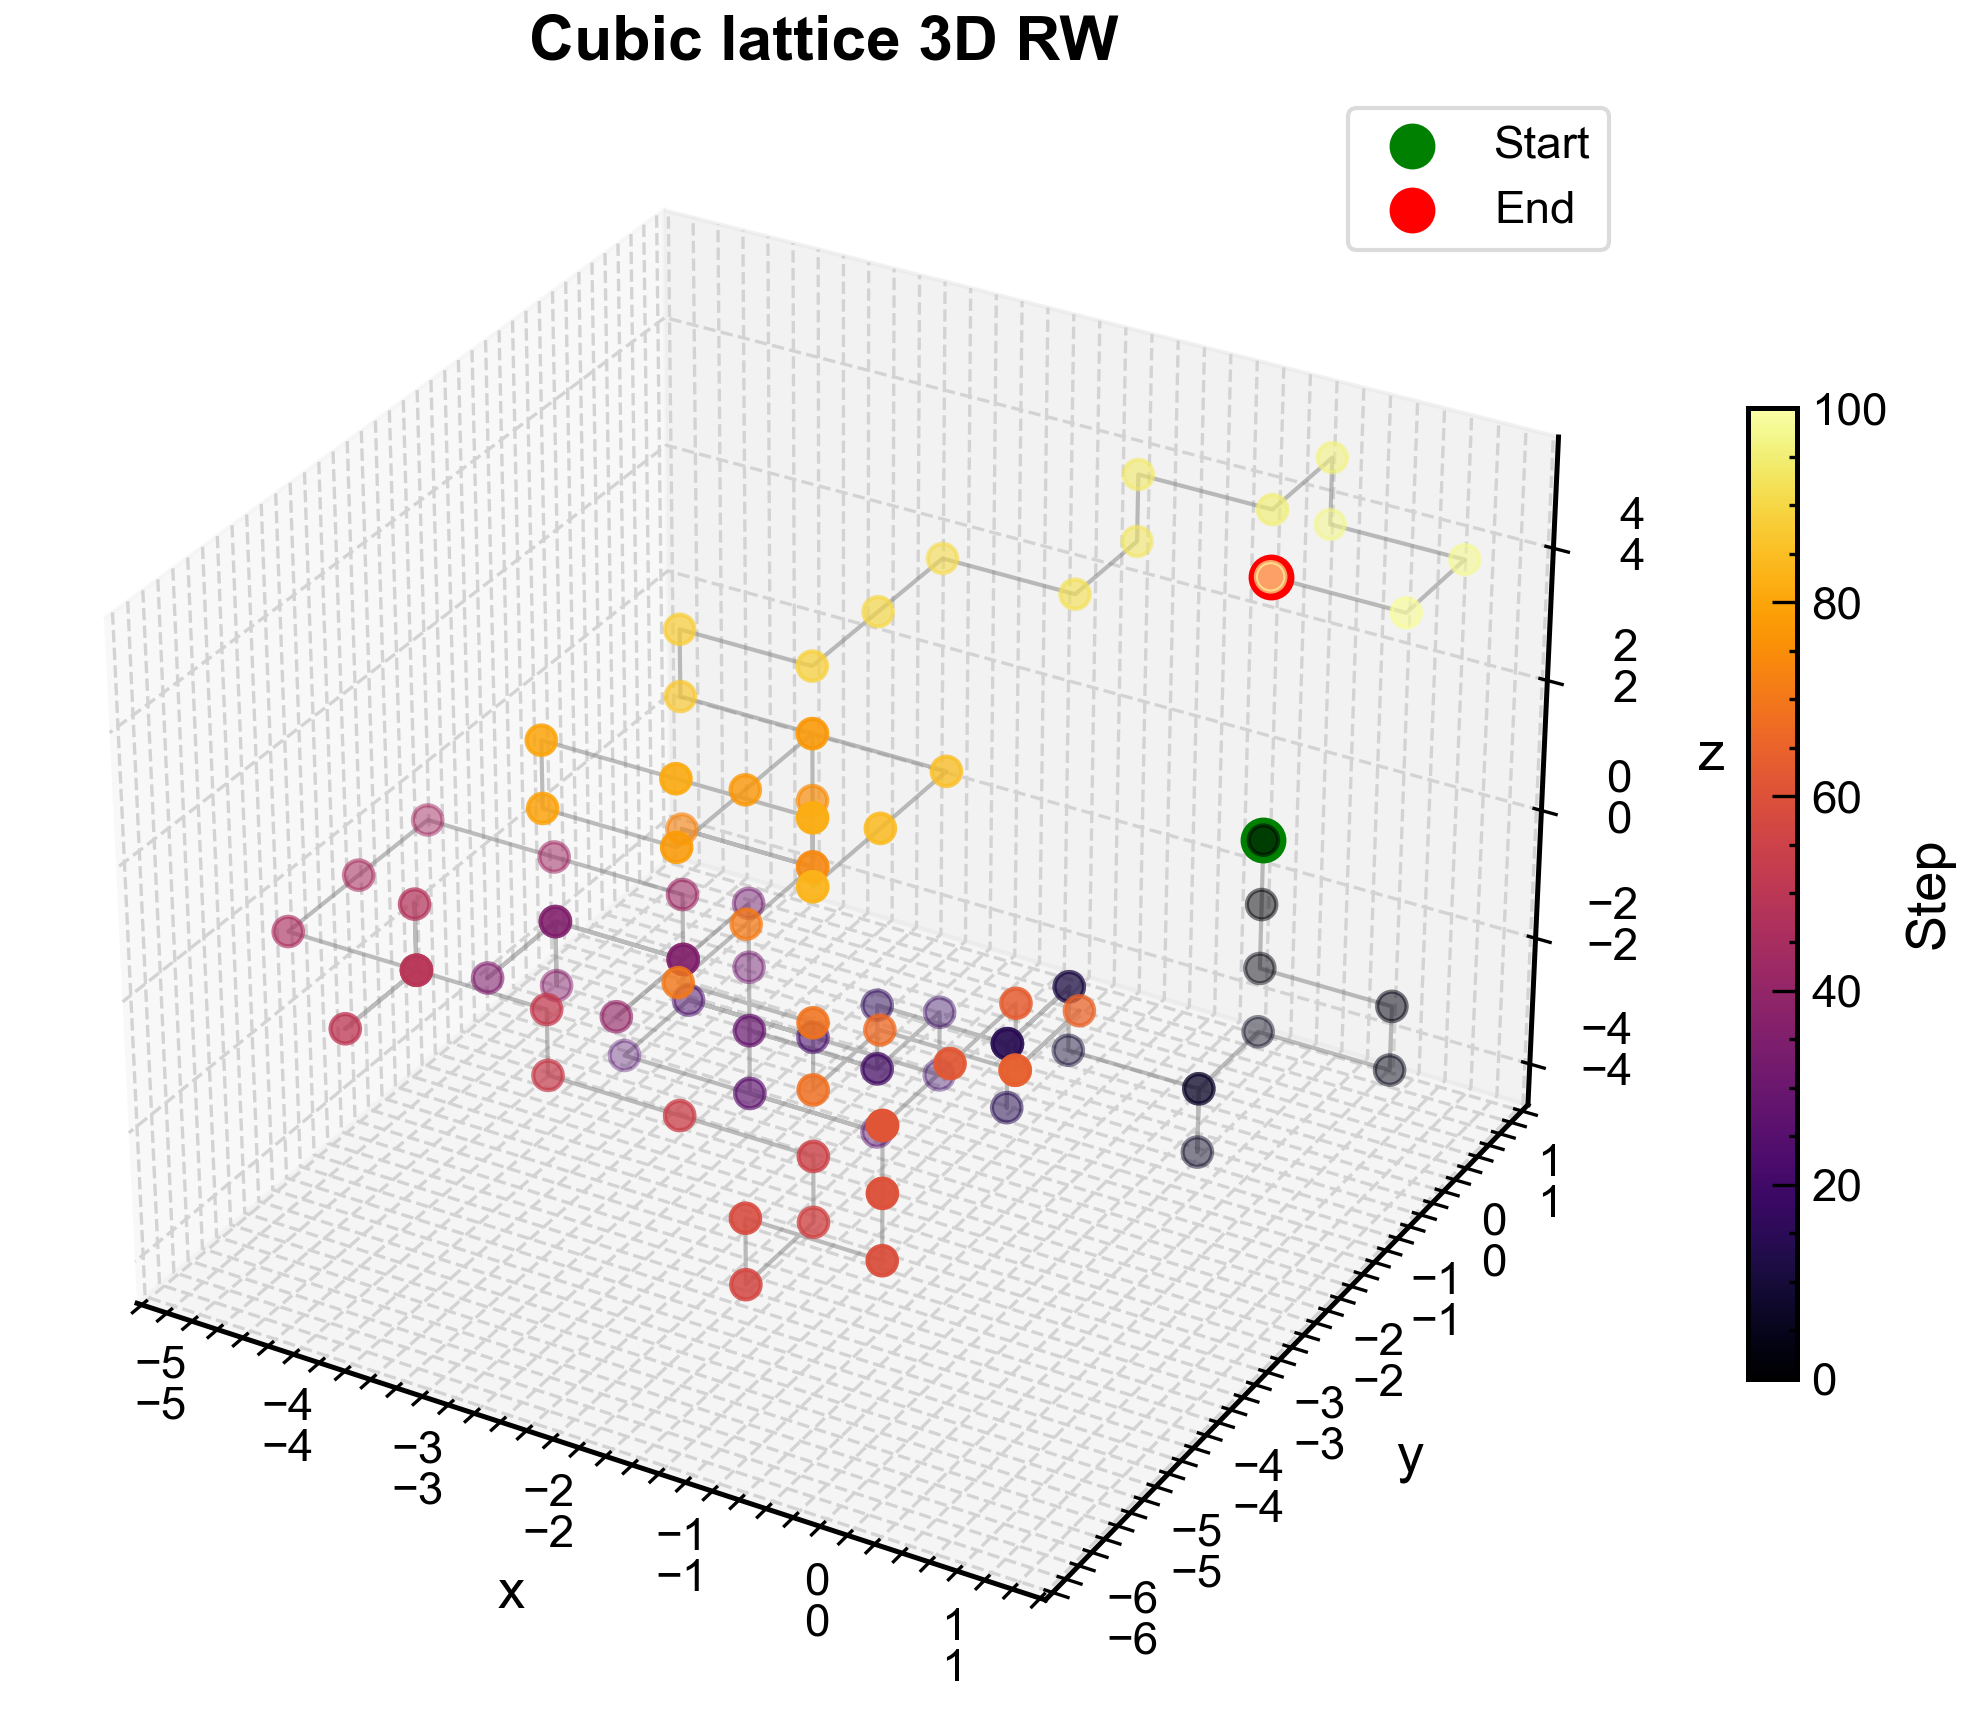

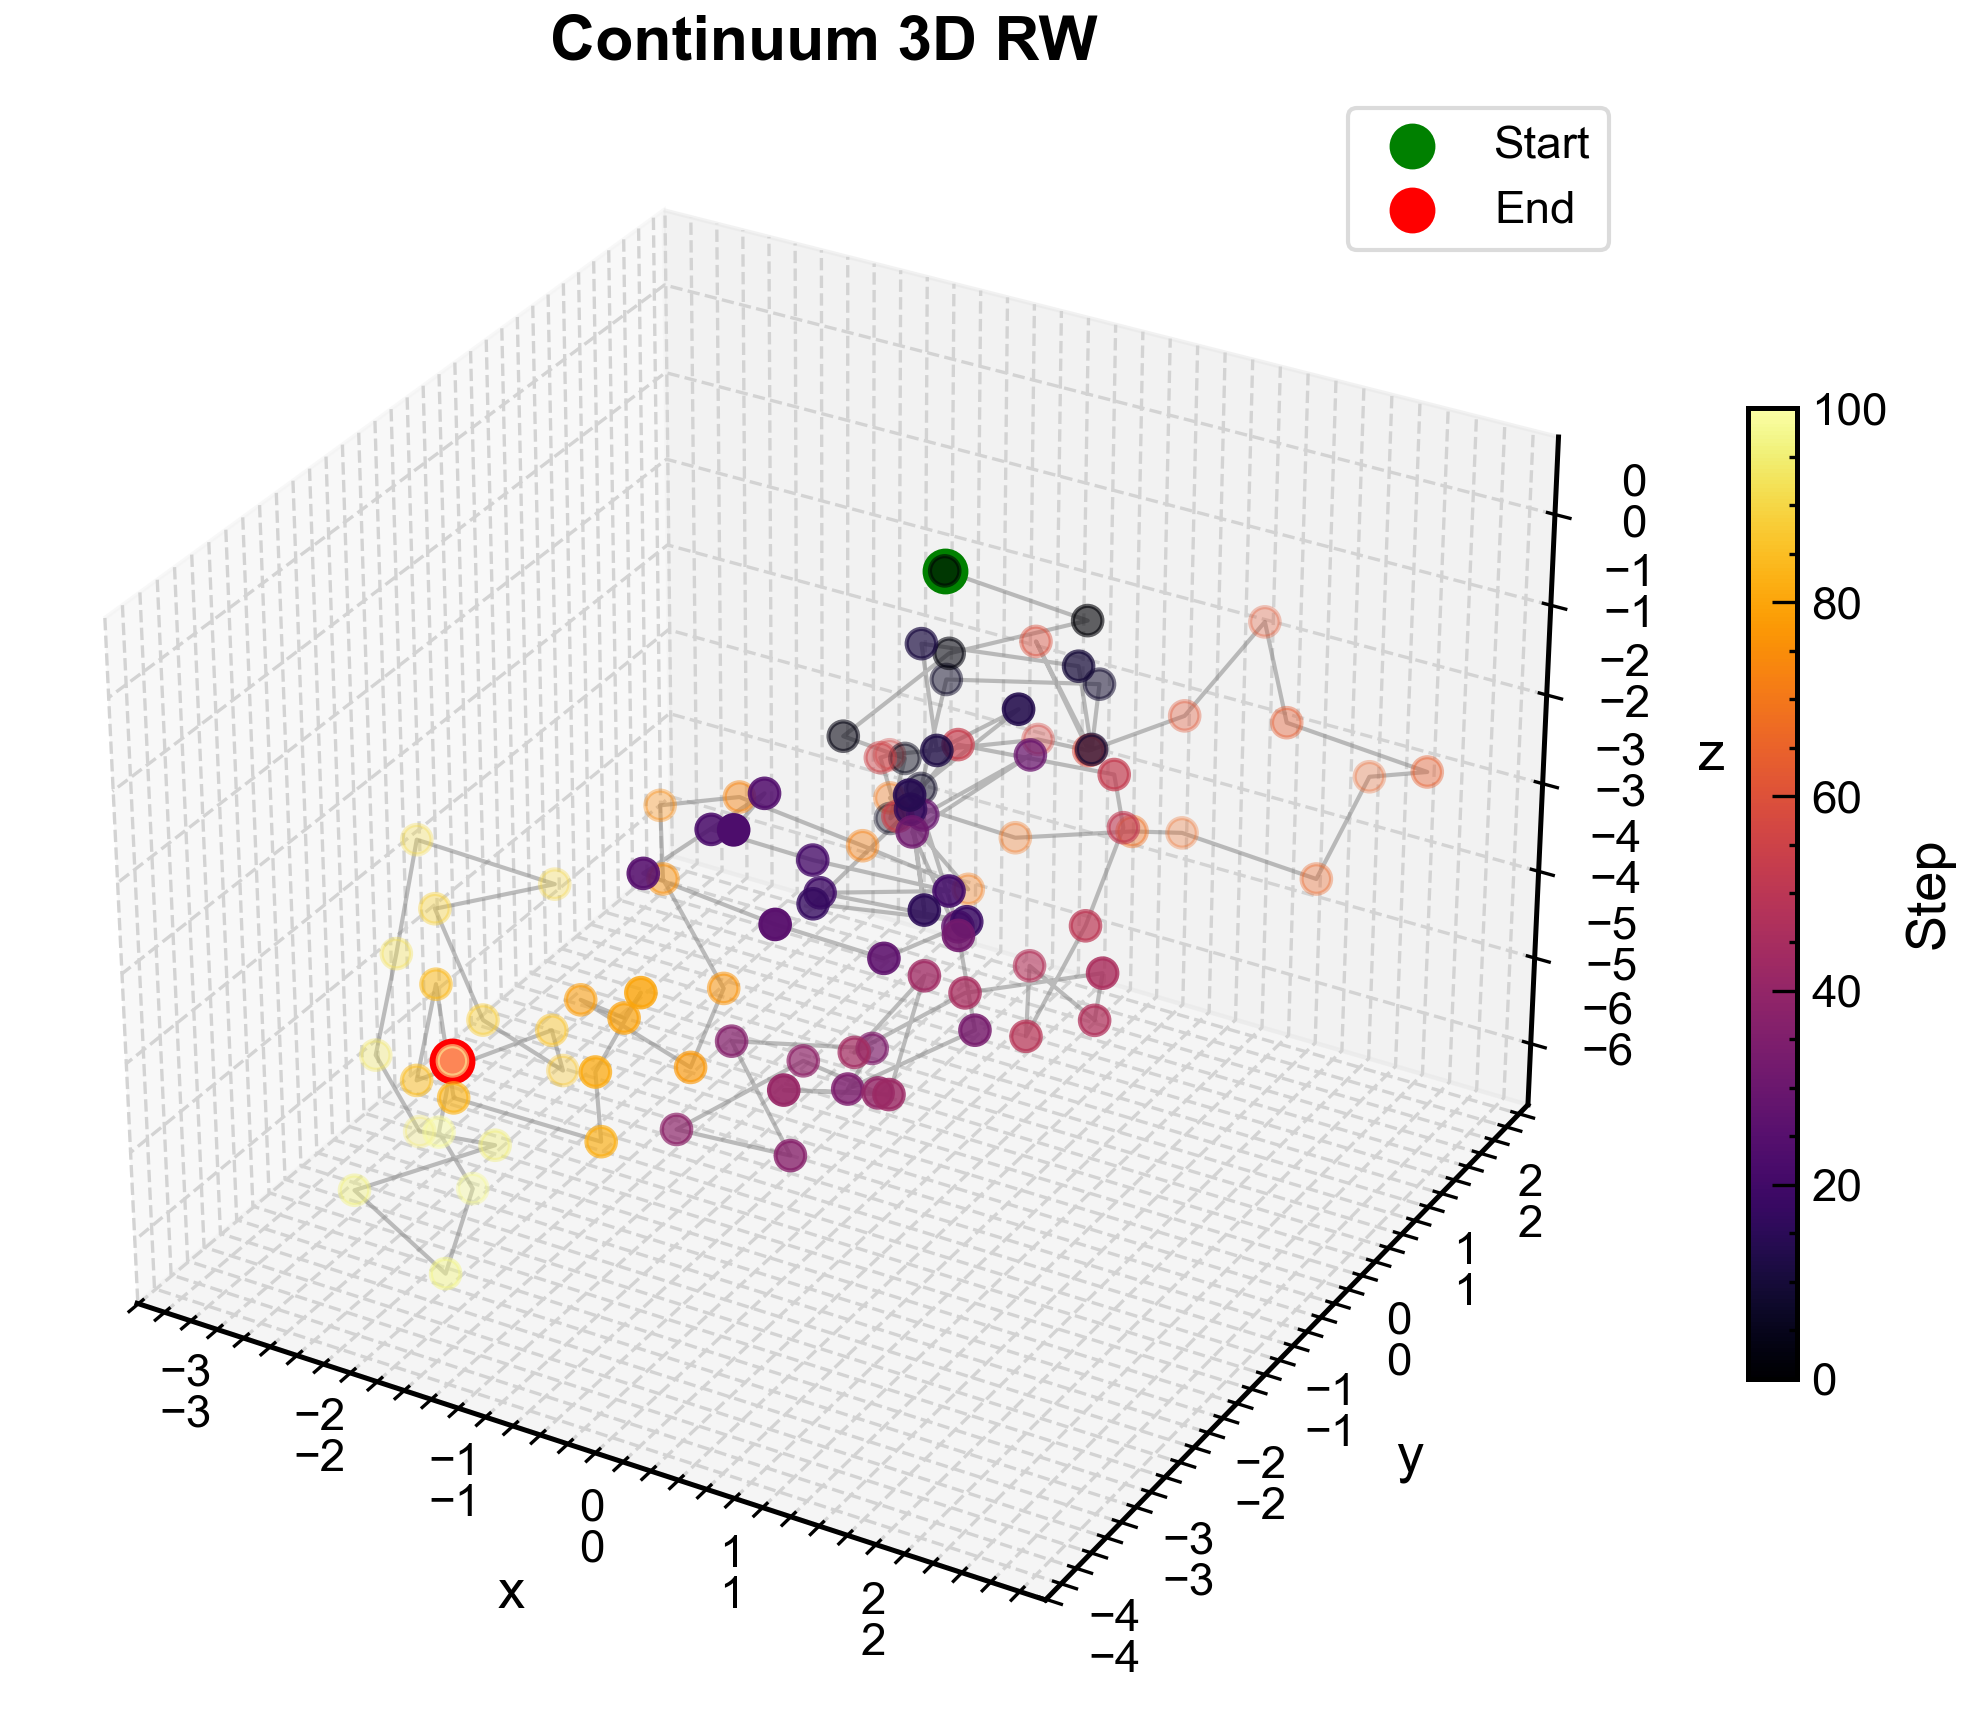

In [5]:
from mpl_toolkits.mplot3d import Axes3D  # Necessario per i plot 3D

n_blocks = 100
RW_type = ["RW_DISCRETE", "RW_CONTINUOUS"]
title = ["Cubic lattice", "Continuum"]

for i in range(2) :

    # Caricamento dati
    step_old,x_old,y_old,z_old = np.loadtxt("es_2.2/" + RW_type[i] + "/OUTPUT/RW/rw_50_" + str(np.random.randint(0, n_blocks + 1)) + ".dat", usecols = (2,3,4,5), unpack = True)

    # Inserisci il punto iniziale (x,y,z) = (0,0,0) e lo step t = 0 alle list
    step = np.insert(step_old, step_old.size, 100)
    x = np.insert(x_old, 0, 0)
    y = np.insert(y_old, 0, 0)
    z = np.insert(z_old, 0, 0)

    # Creazione della figura e dell'asse 3D
    fig = plt.figure(figsize=(10, 7))
    ax = fig.add_subplot(111, projection="3d")

    # Scatter plot 3D con colori in base allo step
    scatter = ax.scatter(x, y, z, c = step, cmap = "inferno", s = 50)

    # Linea che unisce i punti per rappresentare il percorso
    ax.plot(x, y, z, color = 'gray', alpha = 0.5, linewidth = 1)

    # Evidenzia punto iniziale (verde) e finale (rosso)
    ax.scatter(x[0], y[0], z[0], color = "green", s = 100, label = "Start")
    ax.scatter(x[-1], y[-1], z[-1], color = "red", s = 100, label = "End")

    # Colorbar per mostrare la scala dello step
    cbar = plt.colorbar(scatter, ax = ax, shrink = 0.6)
    cbar.set_label("Step")

    # Etichette e titolo
    ax.set_title(title[i] + " 3D RW")
    ax.set_xlabel("x")
    ax.set_ylabel("y")
    ax.set_zlabel("z")
    ax.legend()

    plt.savefig("es_2.2/plot/" + RW_type[i] + "_path.png")

# Mostra il plot
plt.show()